<a href="https://colab.research.google.com/github/arsyad429/Amazon-product-sentiment-analysis-and-classification/blob/main/Weighted_Class_%2B_Undersampling_%2B_Optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [ ]:
!pip install rake_nltk vaderSentiment textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.5 MB/s eta 0:00:00


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.preprocessing import MinMaxScaler
import textstat
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.svm import SVC
import scipy.sparse as sp
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    learning_curve
)

import optuna

# **Dataset Access**

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download(
#     "datafiniti/consumer-reviews-of-amazon-products"
# )

# print("Path to dataset files:", path)

In [ ]:
df = pd.read_csv(f"1429_1.csv")

/tmp/ipykernel_4234/3917178468.py:1: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"1429_1.csv")


# **EDA**

## General Information

In [ ]:
df.head()

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [ ]:
df['reviews.dateSeen'].head()

0    2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z
1    2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z
2    2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z
3    2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z
4    2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z
Name: reviews.dateSeen, dtype: object

In [ ]:
df['reviews.didPurchase'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: reviews.didPurchase, dtype: object

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

In [ ]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince
count,1.0,34131.000000,34627.000000,0.0,0.0
mean,111372787.0,0.630248,4.584573,NaN,NaN
std,NaN,13.215775,0.735653,NaN,NaN
min,111372787.0,0.000000,1.000000,NaN,NaN
25%,111372787.0,0.000000,4.000000,NaN,NaN
50%,111372787.0,0.000000,5.000000,NaN,NaN
75%,111372787.0,0.000000,5.000000,NaN,NaN
max,111372787.0,814.000000,5.000000,NaN,NaN


## Data Insight

### Insight 1

/tmp/ipykernel_4234/2744146840.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='reviews.rating', data=df, palette='Blues_d')


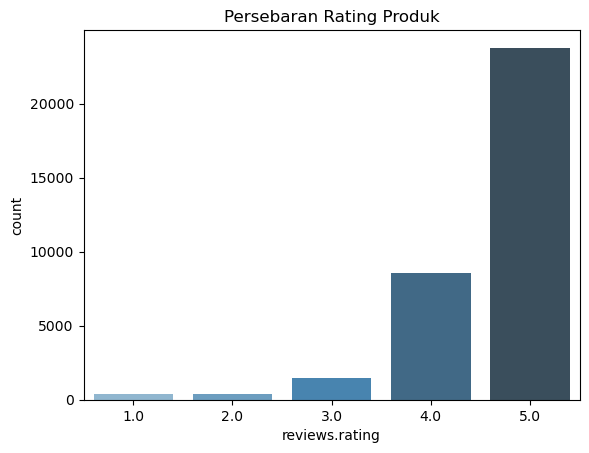

reviews.rating
5.0    68.660294
4.0    24.665723
3.0     4.328992
1.0     1.184047
2.0     1.160944
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='reviews.rating', data=df, palette='Blues_d')
plt.title('Persebaran Rating Produk')
plt.show()

print(df['reviews.rating'].value_counts(normalize=True) * 100)

Insight ini menunjukkan seberapa puas pelanggan secara keseluruhan. Kalau mayoritas rating 5 bintang, artinya produk-produk Amazon umumnya disukai. Tapi kalau ada banyak rating 1-2, itu sinyal ada masalah yang perlu ditelusuri lebih lanjut.
Dari data, mayoritas ulasan memberikan rating 5 bintang (sekitar 23.000+ ulasan), jauh melampaui rating lainnya — menandakan pelanggan secara umum sangat puas dengan produk Amazon.

### Insight 2

) missing from current font.gpu_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


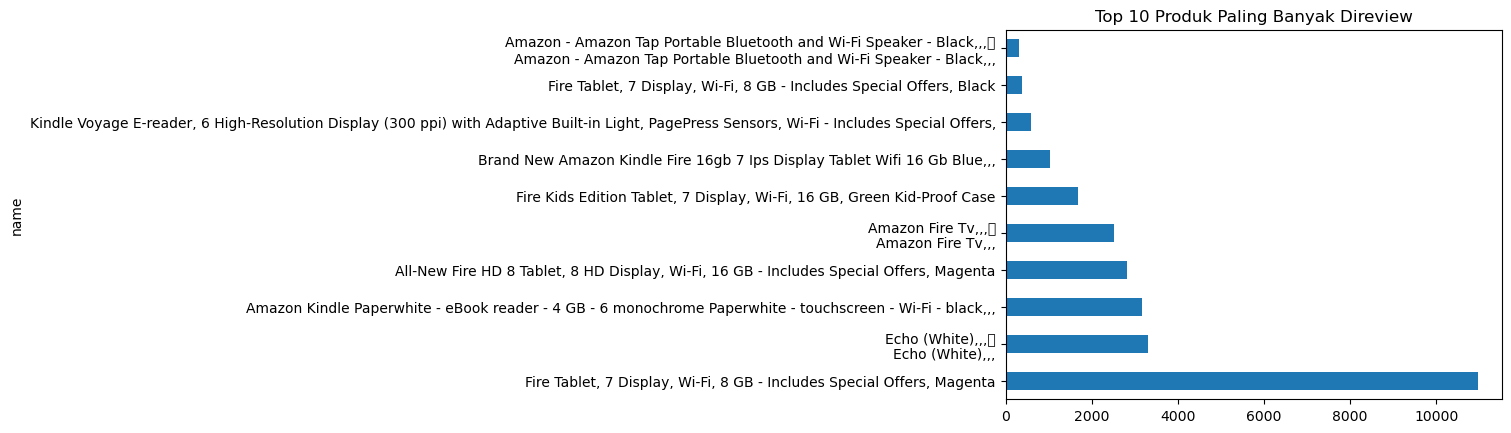

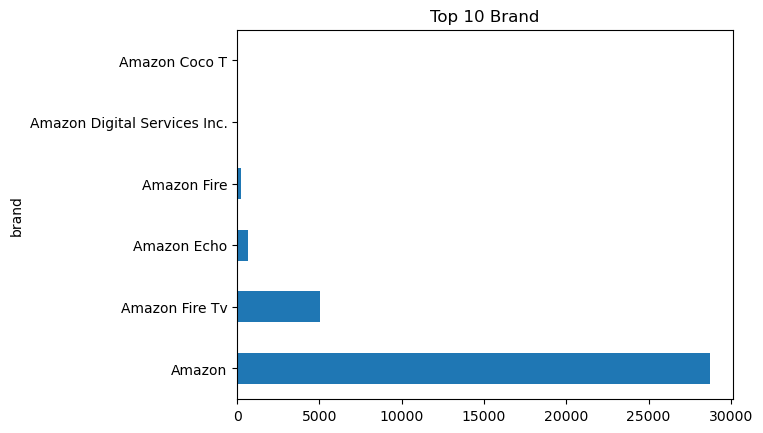

In [ ]:
df['name'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Produk Paling Banyak Direview')
plt.show()

df['brand'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Brand')
plt.show()

Jumlah review mencerminkan seberapa populer suatu produk atau brand. Produk dengan review terbanyak biasanya yang paling banyak dibeli, jadi ini bisa jadi indikator produk unggulan di platform Amazon.
Fire Tablet 7" Magenta menjadi produk paling banyak direview dengan lebih dari 10.000 ulasan, diikuti Echo (White) dan Kindle Paperwhite — menunjukkan dominasi lini tablet dan e-reader Amazon.

Insight 3

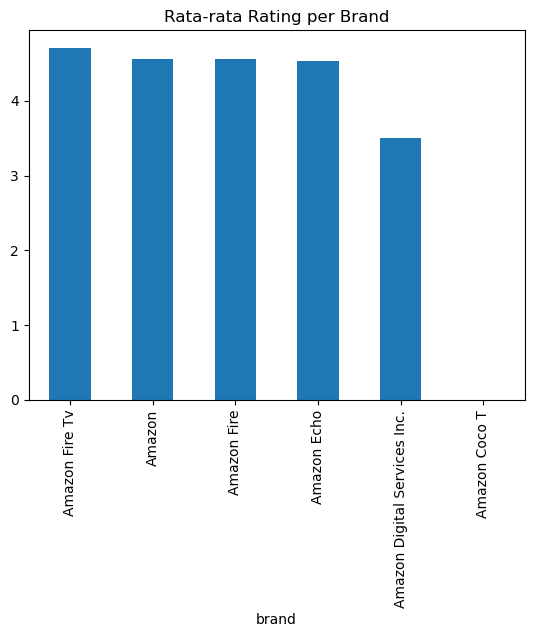

In [ ]:
avg_rating = df.groupby('brand')['reviews.rating'].mean().sort_values(ascending=False).head(10)
avg_rating.plot(kind='bar')
plt.title('Rata-rata Rating per Brand')
plt.show()

Tidak semua brand yang populer punya rating bagus. Insight ini membantu membandingkan kualitas yang dirasakan pelanggan antar brand — brand mana yang konsisten memuaskan, dan mana yang banyak komplain.
Amazon Fire TV memiliki rata-rata rating tertinggi (4.7), sementara Amazon Digital Services Inc. paling rendah (3.5) menunjukkan kepuasan pelanggan bervariasi cukup signifikan antar lini produk.

insight 4

/tmp/ipykernel_4234/2717578376.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = df['reviews.date'].dt.to_period('M')


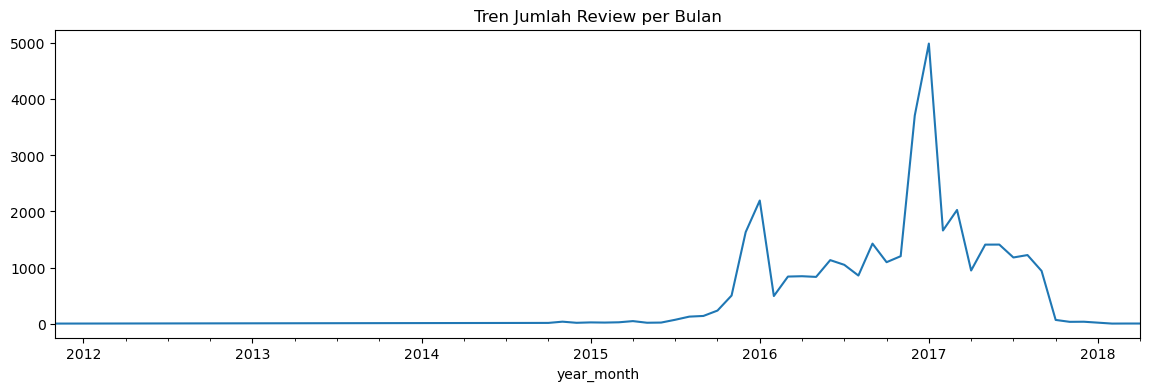

In [ ]:
df['reviews.date'] = pd.to_datetime(df['reviews.date'], utc=True, errors='coerce')
df['year_month'] = df['reviews.date'].dt.to_period('M')

df.groupby('year_month').size().plot(figsize=(14,4))
plt.title('Tren Jumlah Review per Bulan')
plt.show()

Dengan melihat jumlah review per bulan, kita bisa tahu kapan aktivitas belanja paling ramai, misalnya saat musim liburan atau promo besar. Lonjakan tiba-tiba juga bisa menandakan peluncuran produk baru atau viral moment.
Terdapat lonjakan review yang sangat tajam pada awal 2017 (~5.000 ulasan/bulan), kemungkinan besar dipicu oleh peluncuran produk baru atau kampanye promo besar Amazon saat itu.

insight 5

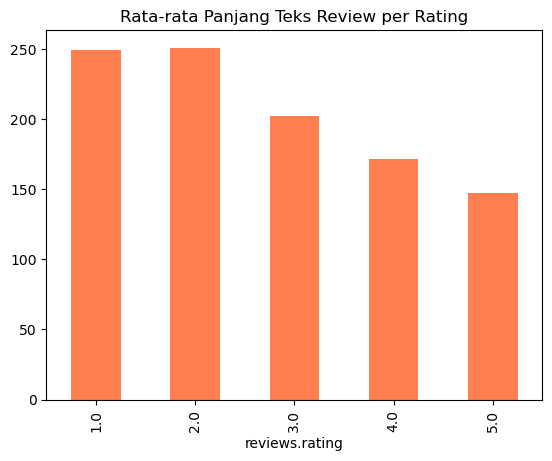

In [ ]:
df['text_length'] = df['reviews.text'].dropna().apply(len)

df.groupby('reviews.rating')['text_length'].mean().plot(kind='bar', color='coral')
plt.title('Rata-rata Panjang Teks Review per Rating')
plt.show()

Pengguna yang kecewa cenderung menulis lebih banyak karena ingin menjelaskan masalahnya secara detail. Kalau rata-rata teks review bintang 1 jauh lebih panjang dari bintang 5, itu pola yang menarik dan umum terjadi di data ulasan produk.
Terbukti, review rating 1 dan 2 memiliki rata-rata panjang teks tertinggi (250 karakter), sedangkan rating 5 paling pendek (148 karakter) — pelanggan yang kecewa memang cenderung lebih banyak bicara.

insight 6

) missing from current font.45.py:10: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from current font.gpu_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


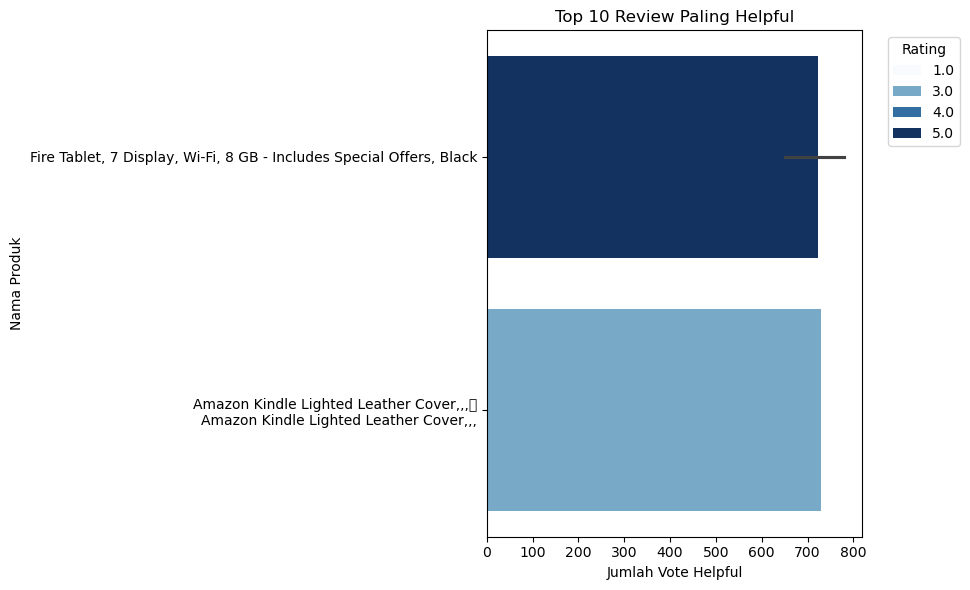

In [ ]:
top_helpful = df.nlargest(10, 'reviews.numHelpful')[['name', 'reviews.rating', 'reviews.numHelpful']]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_helpful, x='reviews.numHelpful', y='name', hue='reviews.rating',
            palette='Blues', dodge=False)
plt.title('Top 10 Review Paling Helpful')
plt.xlabel('Jumlah Vote Helpful')
plt.ylabel('Nama Produk')
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Review yang banyak mendapat vote "helpful" dari pengguna lain biasanya ditulis dengan detail dan jujur — bisa positif maupun negatif. Insight ini membantu memahami jenis konten review yang paling dipercaya oleh calon pembeli.
Hanya 2 produk yang mendominasi vote helpful tertinggi, yaitu Fire Tablet 7" Black (rating 5) dan Amazon Kindle Lighted Leather Cover (rating 3) dengan masing-masing ~720-814 vote — menunjukkan review detail pada produk populer lebih dipercaya pengguna lain.

### Insight 6

/tmp/ipykernel_4234/1077331223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


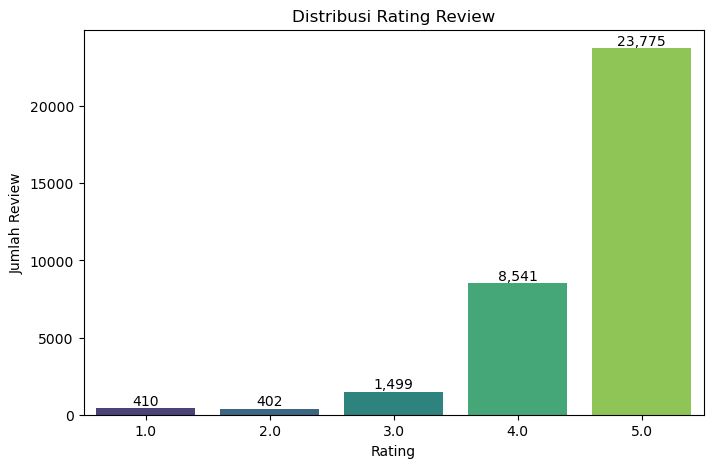

Distribusi Rating:

Rating 1.0: 410 review (1.18%)
Rating 2.0: 402 review (1.16%)
Rating 3.0: 1,499 review (4.33%)
Rating 4.0: 8,541 review (24.67%)
Rating 5.0: 23,775 review (68.66%)

Ringkasan Imbalance:
Mayoritas  : 68.66%
Minoritas  : 1.16%
Rasio imbalance : 59.14x


In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='reviews.rating',
    data=df,
    palette='viridis'
)

plt.title('Distribusi Rating Review')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.show()

rating_counts = df['reviews.rating'].value_counts().sort_index()
rating_percent = df['reviews.rating'].value_counts(normalize=True).sort_index() * 100
print("Distribusi Rating:\n")
for rating in rating_counts.index:
    print(
        f"Rating {rating}: "
        f"{rating_counts[rating]:,} review "
        f"({rating_percent[rating]:.2f}%)"
    )

print("\nRingkasan Imbalance:")
print(f"Mayoritas  : {rating_percent.max():.2f}%")
print(f"Minoritas  : {rating_percent.min():.2f}%")
print(f"Rasio imbalance : {rating_counts.max() / rating_counts.min():.2f}x")

Disini merupakan grafik distribusi rating review, disini bisa dilihat bahwa datanya sangat imbalance dimana rating 5 sangat banyak sekali yaitu 23 ribu data sedangkan rating 4 itu sekitar 8500, dan sisanya sedikit untuk rating 1-3. Ini menunjukkan data imbalance yang severe.

### Insight 7

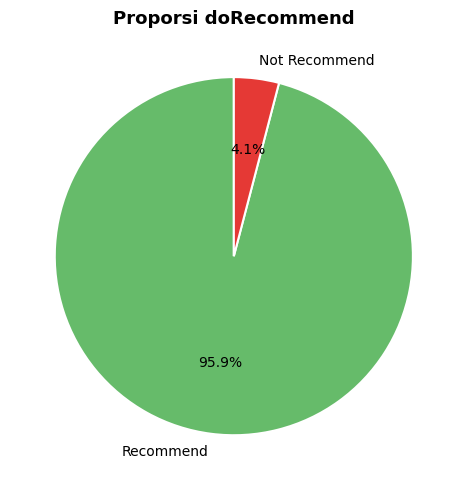

In [ ]:
recommend_counts = df['reviews.doRecommend'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(recommend_counts.values,
        labels=['Recommend', 'Not Recommend'],
        autopct='%1.1f%%',
        colors=['#66bb6a', '#e53935'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title('Proporsi doRecommend', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight  8 Korelasi fitur

In [ ]:
df.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username', 'year_month',
       'text_length'],
      dtype='object')

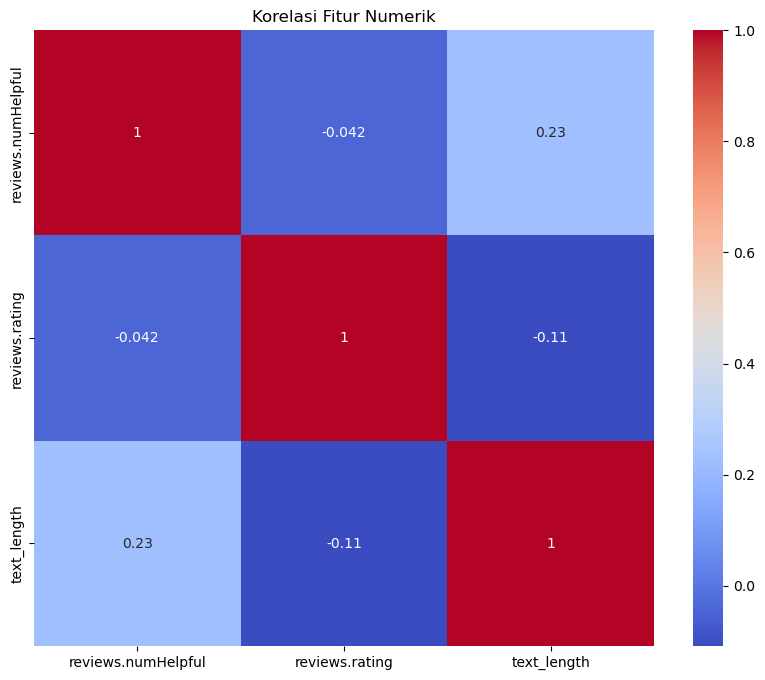

In [ ]:
numerical_col = df.select_dtypes('number').drop(columns=['reviews.id','reviews.userCity', 'reviews.userProvince'])
correlation = numerical_col.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.show()

## Noise or Anomaly Searching

### Anomaly 1 (Missing Value)

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

reviews.userProvince    100.000000
reviews.userCity        100.000000
reviews.id               99.997115
reviews.didPurchase      99.997115
reviews.dateAdded        30.643393
name                     19.503751
reviews.doRecommend       1.713791
reviews.numHelpful        1.526255
year_month                0.351991
reviews.date              0.351991
reviews.rating            0.095211
reviews.username          0.020196
reviews.title             0.017311
asins                     0.005770
reviews.text              0.002885
text_length               0.002885
dtype: float64

Penjelasan: Terdapat anomali berupa missing values yang ekstrem pada beberapa fitur. Kolom *reviews.userCity* dan *reviews.userProvince* memiliki 100% data kosong (0 non-null). Selain itu, kolom *reviews.id* dan *reviews.didPurchase* hanya memiliki 1 baris data yang terisi dari total 34.660 baris. Lalu pada kolom *reviews.text* ada 1 kolom null yang kemungkinan di mana pengguna memberikan rating, namun teks ulasannya kosong (NaN). Kolom-kolom ini adalah noise karena tidak memberikan informasi apa-apa dan sebaiknya di-drop pada tahap preprocessing.

### Anomaly 2 (Mixed Data Types)

In [ ]:
for col in df.columns:
   if len(df[col].apply(type).unique()) > 1:
      print(f"Tipe data unik di kolom '{col}': {df[col].apply(type).unique()}")


Tipe data unik di kolom 'name': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'asins': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.date': [<class 'pandas._libs.tslibs.timestamps.Timestamp'>
 <class 'pandas._libs.tslibs.nattype.NaTType'>]
Tipe data unik di kolom 'reviews.dateAdded': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.didPurchase': [<class 'float'> <class 'bool'>]
Tipe data unik di kolom 'reviews.doRecommend': [<class 'bool'> <class 'float'>]
Tipe data unik di kolom 'reviews.text': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.title': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'reviews.username': [<class 'str'> <class 'float'>]
Tipe data unik di kolom 'year_month': [<class 'pandas._libs.tslibs.period.Period'>
 <class 'pandas._libs.tslibs.nattype.NaTType'>]


Penjelasan : Pada pembacaan dataset terdapat 'warning DtypeWarning: Columns (1,10) have mixed types.' Pandas mendeteksi adanya Mixed Data Types (tipe data campuran) pada saat membaca file CSV, tepatnya pada kolom name dan reviews.didPurchase. Ini berarti dalam satu kolom tersebut, ada baris yang bertipe string, ada yang float (karena NaN), atau boolean. Ini adalah anomali struktur data yang bisa menyebabkan error saat model ML dilatih, sehingga tipe datanya harus diseragamkan.

### Anomaly 3 (Mengecek Duplikasi Data)

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

Jumlah baris duplikat: 0


Penjelasan : Tidak ada data duplikasi data, jadi tidak perlu melakukan preprosesing pada data duplikat.

### Anomaly 4 (Outlier Detection)

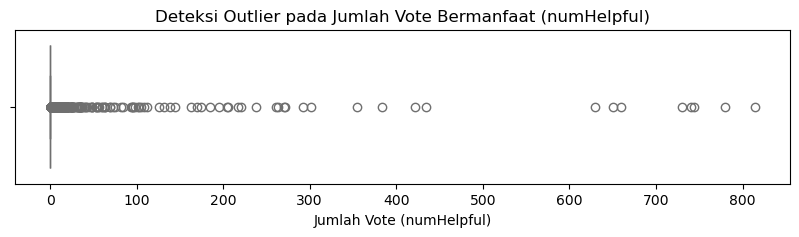

Jumlah ulasan dengan vote 'helpful' lebih dari 50: 58 baris dari total 34660 baris


In [ ]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['reviews.numHelpful'], color='skyblue')
plt.title('Deteksi Outlier pada Jumlah Vote Bermanfaat (numHelpful)')
plt.xlabel('Jumlah Vote (numHelpful)')
plt.show()

outliers_helpful = df[df['reviews.numHelpful'] > 50]
print(f"Jumlah ulasan dengan vote 'helpful' lebih dari 50: {len(outliers_helpful)} baris dari total {len(df)} baris")

Penjelasan : Melalui uji statistik deskriptif (df.describe()) dan visualisasi boxplot, ditemukan adanya outlier yang signifikan pada kolom reviews.numHelpful. Mayoritas ulasan (lebih dari 75%) memiliki nilai 0, namun terdapat beberapa ulasan ekstrem yang mendapat ratusan vote (nilai maksimal 814). Meskipun secara statistik ini adalah outlier, mungkin data ini merupakan kejadian organik yang valid (ulasan viral/informatif), sehingga diputuskan untuk tidak dihapus karena fitur teks ulasannya tetap dapat digunakan untuk melatih model NLP.

### Anomaly 5 (Case Inconsistency)

In [ ]:
import re

sample_texts = df['reviews.text'].dropna().astype(str).tolist()

variasi_amazon = set()
for text in sample_texts:
    matches = re.findall(r'\b[aA][mM][aA][zZ][oO][nN]\b', text)
    variasi_amazon.update(matches)

print("Bukti Anomali Kapitalisasi pada kata 'Amazon':")
print(variasi_amazon)

Bukti Anomali Kapitalisasi pada kata 'Amazon':
{'Amazon', 'amazon', 'AmaZon', 'AMAZON'}


Penjelasan : Melalui eksplorasi teks, ditemukan anomali berupa inkonsistensi kapitalisasi. Sebagai contoh, sebuah entitas yang sama ('Amazon') ditulis dalam berbagai format oleh pengguna yang berbeda. Hal ini merupakan noise karena dalam pemrosesan NLP mentah, komputer akan menganggap kata-kata tersebut sebagai token yang berbeda-beda.

### Anomaly 6 (Punctuation Noise)

In [ ]:
mengandung_simbol = df['reviews.text'].str.contains(r'[^\w\s]', regex=True, na=False)

jumlah_bermasalah = mengandung_simbol.sum()
persentase = (jumlah_bermasalah / len(df)) * 100

print(f"Jumlah ulasan yang mengandung tanda baca/simbol: {jumlah_bermasalah} baris ({persentase:.2f}%)")

print("\nContoh ulasan dengan banyak tanda baca:")
contoh_simbol = df[mengandung_simbol]['reviews.text'].head(3).values
for teks in contoh_simbol:
    print(f"- {teks}")

Jumlah ulasan yang mengandung tanda baca/simbol: 32263 baris (93.08%)

Contoh ulasan dengan banyak tanda baca:
- This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
- great for beginner or experienced person. Bought as a gift and she loves it
- Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...


Penjelasan : Anomali format penulisan terdeteksi pada sebagian besar teks ulasan. Mayoritas pengguna menggunakan tanda baca (koma, titik, tanda hubung) yang sangat bervariasi. Dalam konteks klasifikasi teks dasar, tanda baca ini terhitung sebagai noise yang harus di preprocessing untuk dibersihkan.

### Anomaly 7 (Typo or Slang Vocabulary Noise)

In [ ]:
pip install pyspellchecker

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from spellchecker import SpellChecker

# 1. Menggabungkan semua teks ulasan menjadi satu string raksasa
# Asumsinya teks sudah dalam bentuk lowercase dan tidak ada tanda baca (dari preprocessing kita sebelumnya)
semua_teks = " ".join(df['reviews.text'].dropna())

# 2. Memecah teks menjadi kata per kata dan mengambil kata uniknya saja menggunakan set()
kata_unik = set(semua_teks.split())
print(f"Total kata unik (vocabulary) di dataset: {len(kata_unik)}")

# 3. Inisialisasi SpellChecker bahasa Inggris
spell = SpellChecker()

# 4. Mencari kata yang terindikasi typo/slang (tidak ada di kamus)
kata_aneh = spell.unknown(kata_unik)

print(f"Jumlah kata yang terindikasi typo/slang: {len(kata_aneh)}")
print("\nContoh 50 kata aneh pertama:")
print(list(kata_aneh)[:50])

Total kata unik (vocabulary) di dataset: 37773
Jumlah kata yang terindikasi typo/slang: 23053

Contoh 50 kata aneh pertama:
['television.i', 'respectively.', 'movie/reading', 'specifically.', 'master.', 'it-----------------------------------------*', '(2016)', 'fun.i', 'dots/echos', 'thisome', 'lte', '$130.', 'filling.', 'uv', 'mark,', 'ffiend...', 'correctly.battery', 'machine!', 'problems...', 'free!!', 'answers!', 'any.', ',,,', "request..it's", 'review:sorry', 'him).', 'upgrade?', 'families!', 'dtv', 'modem)', 'supposedly,', 'schooled,', 'add-ons.', 'as.', 'imporoved', 'referral.', 'available.this', 'inlaw', 'tablet).', 'one...get', 'oasis.', 'it...plays', 'voyager,', 'amazontv', 'highschool', 'essential.', 'expensive)', 'it.performance', 'pick!', 'zone".']


# **Preprocessing**

## Anomly and Noise Handling

### 1. Missing values handling

In [ ]:
cols_to_drop = missing_percentage[missing_percentage > 50].index
cols_to_drop

Index(['reviews.didPurchase', 'reviews.id', 'reviews.userCity',
       'reviews.userProvince'],
      dtype='object')

In [ ]:
df_clean = df.copy()
df_clean = df_clean.drop(cols_to_drop, axis=1)
df_clean.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.username', 'year_month', 'text_length'],
      dtype='object')

Di sini kami men-drop kolom yang missing valuenya lebih dari 50%, karena jika diimputasi, maka lebih dari 50% informasi kolom pada dataset akan menjadi informasi palsu semua.

In [ ]:
missing_percentage = df_clean.isna().sum() / len(df_clean) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

reviews.dateAdded      30.643393
name                   19.503751
reviews.doRecommend     1.713791
reviews.numHelpful      1.526255
year_month              0.351991
reviews.date            0.351991
reviews.rating          0.095211
reviews.username        0.020196
reviews.title           0.017311
asins                   0.005770
reviews.text            0.002885
text_length             0.002885
dtype: float64

In [ ]:
df_clean['reviews.dateAdded'].sort_values()

14726    2016-10-15T11:10:42Z
14725    2016-10-15T11:10:42Z
16016    2017-03-06T14:59:25Z
16015    2017-03-06T14:59:25Z
16014    2017-03-06T14:59:25Z
                 ...         
34655                     NaN
34656                     NaN
34657                     NaN
34658                     NaN
34659                     NaN
Name: reviews.dateAdded, Length: 34660, dtype: object

In [ ]:
df_clean['asins']

0        B01AHB9CN2
1        B01AHB9CN2
2        B01AHB9CN2
3        B01AHB9CN2
4        B01AHB9CN2
            ...    
34655    B006GWO5WK
34656    B006GWO5WK
34657    B006GWO5WK
34658    B006GWO5WK
34659    B006GWO5WK
Name: asins, Length: 34660, dtype: object

In [ ]:
df_clean = df_clean.drop(['reviews.dateAdded', 'asins'], axis=1)

Di sini kami drop dateAdded dan asins karena kedua fitur tersebut adalah fitur tidak penting

In [ ]:
df_clean['text_length']

0         143.0
1          75.0
2         131.0
3         593.0
4         613.0
          ...  
34655    1158.0
34656     255.0
34657     314.0
34658     231.0
34659     468.0
Name: text_length, Length: 34660, dtype: float64

In [ ]:
df_clean['text_length'] = df_clean['text_length'].fillna(len(df_clean['reviews.text']))

text length ini berisi panjang text reviews, jadi imputasitasinya tinggal pake len aja.

In [ ]:
df_clean['reviews.doRecommend'].isna().sum()

594

In [ ]:
df_clean = df_clean.dropna(subset=['reviews.doRecommend'])

In [ ]:
df_clean['reviews.doRecommend'].unique()

array([True, False], dtype=object)

Karena di sini yg hilang cuma 594 dari 30rb an data, jadi daripada memberikan infromasi palsu, mending di drop aja

In [ ]:
df_clean['reviews.username'] = df_clean['reviews.username'].fillna('Unknown')
df_clean['reviews.title'] = df_clean['reviews.title'].fillna('Unknown')
df_clean['name'] = df_clean['name'].fillna('Unknown')

In [ ]:
df_clean['reviews.numHelpful'].unique()

array([  0.,   1.,   2.,   3.,  55.,   4.,  24.,  11.,  42.,  62.,   7.,
         8.,   6.,  10.,  36.,  16.,  15.,  13.,   5.,   9., 105.,  25.,
        21.,  14.,  20.,  22.,  12.,  96., 102.,  34.,  17.,  73., 109.,
        19.,  27.,  39.,  57.,  18.,  40.,  33.,  28., 103.,  26.,  32.,
        43.,  37.,  64.,  23.,  48.,  49.,  95.,  31.,  63.,  nan,  54.,
        30.,  46.,  69.])

untuk username, name, dan title, karena kalau pakai modus bakal ga akurat, maka di sini kami isi dengan Unknown saja

In [ ]:
df_clean['reviews.numHelpful'].isna().sum()

2

In [ ]:
df_clean = df_clean.dropna(subset=['reviews.numHelpful'])

In [ ]:
missing_percentage = df_clean.isna().sum() / len(df_clean) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

Series([], dtype: float64)

### 2. Mixed Data types handling

In [ ]:
for col in df_clean.columns:

    if len(df_clean[col].apply(type).unique()) > 1:
       print(f"Tipe data unik di kolom '{col}': {df_clean[col].apply(type).unique()}")


Karena kita telah menghilangkan missing value, maka sekarang sudah tidak ada kolom dengan tipe data yg tercapur

### 3. Case Inconsistency handling

In [ ]:
categorical_col = df_clean.select_dtypes('object').columns
categorical_col

Index(['id', 'name', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.dateSeen', 'reviews.doRecommend', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username'],
      dtype='object')

In [ ]:
for col in categorical_col:
    df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()

In [ ]:
sample_texts = df_clean['reviews.text'].dropna().astype(str).tolist()

variasi_amazon = set()
for text in sample_texts:
    matches = re.findall(r'\b[aA][mM][aA][zZ][oO][nN]\b', text)
    variasi_amazon.update(matches)

print("Bukti Anomali Kapitalisasi pada kata 'Amazon':")
print(variasi_amazon)

Bukti Anomali Kapitalisasi pada kata 'Amazon':
{'amazon'}


Untuk case yang tidak konsistem di sini kami lower kan dan hilangkan spasi kanan kirinya biar konsisten

### 4. Punctuation noise handling

In [ ]:
df_clean['reviews.text']

0        this product so far has not disappointed. my c...
1        great for beginner or experienced person. boug...
2        inexpensive tablet for him to use and learn on...
3        i've had my fire hd 8 two weeks now and i love...
4        i bought this for my grand daughter when she c...
                               ...                        
34620    i am now able to stream tv and movies from aro...
34621    best streaming device , very portable , amazin...
34622    simply the best to watch tv series and movies....
34623    i was looking for ways to cut cost from a rais...
34624    i enjoy my kindle tv, it beats paying for cabl...
Name: reviews.text, Length: 34064, dtype: object

In [ ]:
# 1. Mengganti semua karakter selain huruf, angka (\w), dan whitespace (\s) dengan spasi (' ')
df_clean['reviews.text'] = df_clean['reviews.text'].str.replace(r'[^\w\s]', ' ', regex=True)

# 2. Membersihkan spasi ganda/berlebih yang mungkin terbentuk dari langkah pertama
df_clean['reviews.text'] = df_clean['reviews.text'].str.replace(r'\s+', ' ', regex=True)

# 3. (Opsional) Memastikan tidak ada spasi nyangkut di awal atau akhir kalimat lagi
df_clean['reviews.text'] = df_clean['reviews.text'].str.strip()

In [ ]:
mengandung_simbol = df_clean['reviews.text'].str.contains(r'[^\w\s]', regex=True, na=False)

jumlah_bermasalah = mengandung_simbol.sum()
persentase = (jumlah_bermasalah / len(df_clean)) * 100

print(f"Jumlah ulasan yang mengandung tanda baca/simbol: {jumlah_bermasalah} baris ({persentase:.2f}%)")

print("\nContoh ulasan dengan banyak tanda baca:")
contoh_simbol = df_clean[mengandung_simbol]['reviews.text'].head(3).values
for teks in contoh_simbol:
    print(f"- {teks}")

Jumlah ulasan yang mengandung tanda baca/simbol: 0 baris (0.00%)

Contoh ulasan dengan banyak tanda baca:


di sini kami mengganti tanda baca dan symbol dengan spasi kosong agar tidak merusak hassil dari TFIDF nanti, lalu setelah itu kami juga menghapus spasi ganda jika dari pemrosesan sebelumnya menghasilkan spasi ganda.

In [ ]:
df_clean['reviews.text'].iloc[0]

'this product so far has not disappointed my children love to use it and i like the ability to monitor control what content they see with ease'

### 5. Typo or Slang Vocabulary Noise handling

In [ ]:
# 1. Menggabungkan semua teks ulasan menjadi satu string raksasa
# Asumsinya teks sudah dalam bentuk lowercase dan tidak ada tanda baca (dari preprocessing kita sebelumnya)
semua_teks = " ".join(df_clean['reviews.text'].dropna())

# 2. Memecah teks menjadi kata per kata dan mengambil kata uniknya saja menggunakan set()
kata_unik = set(semua_teks.split())
print(f"Total kata unik (vocabulary) di dataset: {len(kata_unik)}")

# 3. Inisialisasi SpellChecker bahasa Inggris
spell = SpellChecker()

# 4. Mencari kata yang terindikasi typo/slang (tidak ada di kamus)
kata_aneh = spell.unknown(kata_unik)

print(f"Jumlah kata yang terindikasi typo/slang: {len(kata_aneh)}")
print("\nContoh 50 kata aneh pertama:")
print(list(kata_aneh)[:50])

Total kata unik (vocabulary) di dataset: 13564
Jumlah kata yang terindikasi typo/slang: 3446

Contoh 50 kata aneh pertama:
['vid', 'mircosd', 'azi', 'netfliz', 'chromebooks', 'ereaders', 'gir', 'setupapp', 'expirence', 'satisfly', 'clinicals', 'tetevision', 'smallfootprint', 'ecco', 'wemo', 'vue', 'k8d', 'couldn', 'mancave', 'sned', '11yr', 'philps', 'yrs', '3yo', 'sgould', 'ahs8n', 'ittle', 'thisome', 'lte', 'convient', 'grnaddaughter', 'availabilty', 'completly', '3streaming', 'uv', 'inthe', 'deliverd', 'wasn', '21st', 'tt', 'bith', 'planty', 'expirience', 'covererd', 'todays', 'yoi', 'desent', 'soundlink', 'installedcons', '6years']


**Nanti di TF IDF pake parameter min_df aja wkwkwk**

## Feature Engineering

In [ ]:
df_clean = df.dropna(subset=['reviews.text', 'reviews.rating']).copy()
df_clean['reviews.rating'] = pd.to_numeric(df_clean['reviews.rating'], errors='coerce')
df_clean = df_clean.dropna(subset=['reviews.rating']).reset_index(drop=True)

print(f"Shape setelah drop NaN: {df_clean.shape}")

Shape setelah drop NaN: (34626, 23)


Disini kami menghapus baris yang tidak punya reviews.text atau reviews.rating.

In [ ]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df_clean['sentiment'] = df_clean['reviews.rating'].apply(rating_to_sentiment)
print("Distribusi Label Sentimen:")
print(df_clean['sentiment'].value_counts())

Distribusi Label Sentimen:
sentiment
Positif    32315
Netral      1499
Negatif      812
Name: count, dtype: int64


/tmp/ipykernel_4234/883999072.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment', data=df_clean, palette='Set2')


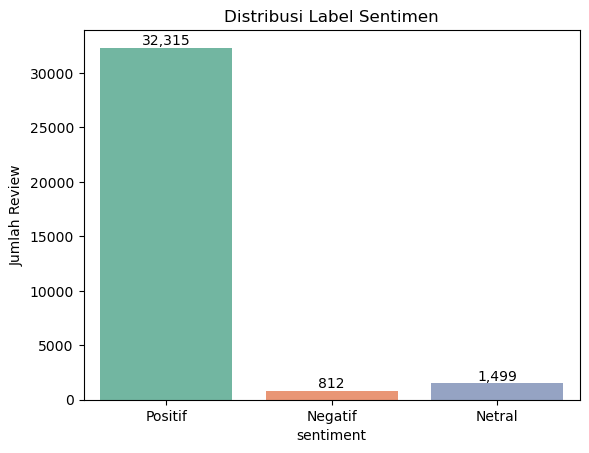

In [ ]:
ax = sns.countplot(x='sentiment', data=df_clean, palette='Set2')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Label Sentimen')
plt.ylabel('Jumlah Review')
plt.show()

Setelah melakukan binning dan membuat Label sentimen, bisa dilihat bahwa hasilnya sangat imbalance sekali yaitu lebih dari 32 ribu merupakan positif, sedangkan netral dan negatif dibawah 1.5 ribu

### Undersampling kelas positive

In [ ]:
# 1. Pisahkan data berdasarkan masing-masing kelas
df_positif = df_clean[df_clean['sentiment'] == 'Positif']
df_negatif = df_clean[df_clean['sentiment'] == 'Negatif']
df_netral = df_clean[df_clean['sentiment'] == 'Netral']

# 2. Lakukan Random Undersampling pada kelas Positif
# n = 900 adalah jumlah data yang ingin disisakan
# random_state = 42 digunakan agar hasil acak selalu sama (reproducible) setiap kali kode dijalankan
df_positif_undersampled = df_positif.sample(n=900, random_state=42)

# 3. Gabungkan kembali data yang sudah di-undersample dengan kelas lainnya
df_balanced = pd.concat([df_positif_undersampled, df_negatif, df_netral])

# 4. Acak urutan baris dataframe baru (Shuffle)
# Ini penting agar saat model dilatih, data tidak masuk secara berurutan (positif semua, lalu negatif semua)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Cek distribusi data setelah undersampling
print("Distribusi Kelas Setelah Undersampling:")
print(df_balanced['sentiment'].value_counts())

Distribusi Kelas Setelah Undersampling:
sentiment
Netral     1499
Positif     900
Negatif     812
Name: count, dtype: int64


Di sini saya potong secara random untuk kelas positifnya jadi 900

In [ ]:
df_balanced['text_length'] = df_balanced['reviews.text'].str.len()
df_balanced['word_count']  = df_balanced['reviews.text'].str.split().str.len()

print("\nStatistik Fitur Numerik Baru:")
print(df_balanced[['text_length', 'word_count']].describe().round(2))


Statistik Fitur Numerik Baru:
       text_length  word_count
count      3211.00     3211.00
mean        200.46       38.20
std         206.51       38.76
min           3.00        1.00
25%          78.00       15.00
50%         128.00       25.00
75%         245.50       47.00
max        1844.00      354.00


Menambahkan fitur baru saja yaitu text_length dan word_count

In [ ]:
le = LabelEncoder()
df_balanced['label'] = le.fit_transform(df_balanced['sentiment'])

print("Pemetaan Label:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {enc}")

Pemetaan Label:
  Negatif → 0
  Netral → 1
  Positif → 2


In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

resources = [
    'punkt',
    'stopwords',
    'wordnet',
    'omw-1.4',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'vader_lexicon'
]

for r in resources:
    nltk.download(r)
!pip install contractions

[nltk_data] Downloading package punkt to /home/arsyad/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/arsyad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/arsyad/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/arsyad/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/arsyad/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/arsyad/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/arsyad/nltk_data...
[nltk_data]   Package v

In [ ]:
import contractions

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess_text(text):
    # A. Case Folding & Cleaning (Huruf kecil & hapus tanda baca)
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = contractions.fix(text) # Menggunakan library, lebih komprehensif

    # B. Tokenizing (Memecah kalimat menjadi kata)
    tokens = word_tokenize(text)

    clean_tokens = []
    for word in tokens:
        # C. Stop Words Removal (Abaikan kata jika ada di dalam daftar stop words)
        if word not in stop_words:
            # D. Lemmatization (Mengubah kata ke bentuk dasar)
            # pos='v' berarti kita asumsikan kata tersebut adalah verb (kata kerja)
            # pos='n' untuk noun (kata benda). NLTK secara default menggunakan 'n'.

            # Agar simpel di contoh ini, kita lemmatize kata kerjanya dulu, lalu kata bendanya
            lemma_verb = lemmatizer.lemmatize(word, pos='v')
            lemma_final = lemmatizer.lemmatize(lemma_verb, pos='n')

            clean_tokens.append(lemma_final)

    # E. Gabungkan kembali token menjadi string (karena TF-IDF butuh input string utuh)
    return " ".join(clean_tokens)

In [ ]:
# --- 1. FITUR INDEPENDEN

vader_analyzer = SentimentIntensityAnalyzer()
!pip install rake_nltk vaderSentiment textstat
def get_vader_compound(text):
    """Mengambil skor gabungan VADER dari teks mentah."""
    return vader_analyzer.polarity_scores(str(text))['compound']

def get_readability_score(text):
    """Mengambil skor Flesch Reading Ease dari teks mentah."""
    text_str = str(text)
    if len(text_str.split()) < 3:
        return 0
    return textstat.flesch_reading_ease(text_str)

def get_pos_noun_verb_ratio(text):
    """Menghitung rasio Noun dan Verb sebagai representasi POS tagging"""
    tokens = nltk.word_tokenize(str(text))
    pos_tags = nltk.pos_tag(tokens)

    counts = nltk.FreqDist(tag[:2] for word, tag in pos_tags)
    total = max(len(tokens), 1)

    return counts.get('NN', 0) / total, counts.get('VB', 0) / total

# --- 2. FITUR DEPENDEN
def apply_lda_features(X_train_text, X_test_text, n_topics=5):
    """
    Melakukan ekstraksi probabilitas topik LDA.
    Harus menggunakan raw token counts (CountVectorizer), bukan TF-IDF.
    """
    # Fit pada training data
    tf_vectorizer = CountVectorizer(max_features=1000, stop_words='english')
    X_train_tf = tf_vectorizer.fit_transform(X_train_text)
    X_test_tf = tf_vectorizer.transform(X_test_text)

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)

    # Fit LDA hanya pada data training, transform ke train dan test
    train_lda_features = lda.fit_transform(X_train_tf)
    test_lda_features = lda.transform(X_test_tf)

    return train_lda_features, test_lda_features

In [ ]:
df_balanced['combined_raw'] = df_balanced['reviews.title'].fillna('') + ' ' + df_balanced['reviews.text'].fillna('')

# Preprocessing teks
df_balanced['combinedtext_exp'] = df_balanced['combined_raw'].apply(preprocess_text)

# Ekstraksi fitur numerik dari teks dasar
df_balanced['textlength_exp'] = df_balanced['combinedtext_exp'].str.len()
df_balanced['wordcount_exp'] = df_balanced['combinedtext_exp'].str.split().str.len()

In [ ]:
df_balanced['vader_score'] = df_balanced['combined_raw'].apply(get_vader_compound)
df_balanced['readability'] = df_balanced['combined_raw'].apply(get_readability_score)

# Apply POS tagging dan pecah menjadi 2 kolom
df_balanced[['noun_ratio', 'verb_ratio']] = pd.DataFrame(
    df_balanced['combined_raw'].apply(get_pos_noun_verb_ratio).tolist(),
    index=df_balanced.index
)

In [ ]:
# Cek kolom mana saja yang menyimpan nilai NaN dan berapa jumlahnya
print("=== Jumlah NaN di tiap kolom ===")
print(df_balanced[['textlength_exp', 'wordcount_exp', 'vader_score', 'readability', 'noun_ratio', 'verb_ratio']].isna().sum())

# Tampilkan 5 baris sampel data yang mengandung NaN untuk dianalisis teks aslinya
print("\n=== Contoh Baris yang Mengandung NaN ===")
nan_rows = df_balanced[df_balanced[['vader_score', 'readability', 'noun_ratio', 'verb_ratio']].isna().any(axis=1)]
print(nan_rows[['combined_raw', 'combinedtext_exp']].head())

=== Jumlah NaN di tiap kolom ===
textlength_exp    0
wordcount_exp     0
vader_score       0
readability       0
noun_ratio        0
verb_ratio        0
dtype: int64

=== Contoh Baris yang Mengandung NaN ===
Empty DataFrame
Columns: [combined_raw, combinedtext_exp]
Index: []


In [ ]:
X = df_balanced[['combinedtext_exp', 'combined_raw', 'reviews.numHelpful', 'textlength_exp', 'wordcount_exp', 'vader_score', 'readability', 'noun_ratio', 'verb_ratio']]
y = df_balanced['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=33, stratify=y
)

print("New splits created including feature columns.")
print("Distribusi y_train:", Counter(y_train))

New splits created including feature columns.
Distribusi y_train: Counter({1: 1199, 2: 720, 0: 649})


Penjelasan: Melakukan train_test_split sebelum ekstraksi fitur menggunakan TF-IDF untuk mencegah data leakage. Jika dilakukan TF-IDF dulu, nanti data train bisa melihat data test.

In [ ]:
tfidf_exp = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

# TF-IDF
X_traintext_exp = tfidf_exp.fit_transform(X_train['combinedtext_exp'])
X_testtext_exp = tfidf_exp.transform(X_test['combinedtext_exp'])

# LDA Features
train_lda, test_lda = apply_lda_features(X_train['combinedtext_exp'], X_test['combinedtext_exp'])

# Scaling numerical features (Fixing the KeyError by ensuring these exist in the split)
num_cols_exp = ['reviews.numHelpful', 'textlength_exp', 'wordcount_exp',
                'vader_score', 'readability', 'noun_ratio', 'verb_ratio']

scaler_exp = MinMaxScaler()
X_trainnum_exp = scaler_exp.fit_transform(X_train[num_cols_exp])
X_testnum_exp = scaler_exp.transform(X_test[num_cols_exp])

X_trainnum_exp = np.nan_to_num(X_trainnum_exp, nan=0.0)
X_testnum_exp = np.nan_to_num(X_testnum_exp, nan=0.0)

# Final Horizontal Stack
X_train_tfidf = sp.hstack(
    [X_traintext_exp, sp.csr_matrix(X_trainnum_exp), sp.csr_matrix(train_lda)],
    format='csr'
)

X_test_tfidf = sp.hstack(
    [X_testtext_exp, sp.csr_matrix(X_testnum_exp), sp.csr_matrix(test_lda)],
    format='csr'
)

print("Ukuran data training eksperimen:", X_train_tfidf.shape)
print("Ukuran data testing eksperimen :", X_test_tfidf.shape)

Ukuran data training eksperimen: (2568, 4052)
Ukuran data testing eksperimen : (643, 4052)


In [ ]:
# Cek komponen teks TF-IDF
print("Apakah X_traintext_exp mengandung NaN?", np.isnan(X_traintext_exp.data).any())

# Cek komponen numerik hasil scaling
print("Apakah X_trainnum_exp mengandung NaN?", np.isnan(X_trainnum_exp).any())

# Cek komponen LDA (Kecurigaan terbesar kita)
print("Apakah train_lda mengandung NaN?", np.isnan(train_lda).any())

# Cek matriks final gabungan
print("Apakah X_train_tfidf final mengandung NaN?", np.isnan(X_train_tfidf.data).any())

# Cek target variable
print("Apakah y_train mengandung NaN?", pd.Series(y_train).isna().any())

Apakah X_traintext_exp mengandung NaN? False
Apakah X_trainnum_exp mengandung NaN? False
Apakah train_lda mengandung NaN? False
Apakah X_train_tfidf final mengandung NaN? False
Apakah y_train mengandung NaN? False


In [ ]:
# tfidf = TfidfVectorizer(
#     max_features=10000,
#     ngram_range=(1, 2),
#     min_df=2,
#     max_df=0.95
# )

# X_train_tfidf = tfidf.fit_transform(X_train)
# X_test_tfidf  = tfidf.transform(X_test)
# print(f"Shape X_train TF-IDF : {X_train_tfidf.shape}")
# print(f"Shape X_test  TF-IDF : {X_test_tfidf.shape}")

# feature_names = tfidf.get_feature_names_out()
# mean_tfidf = X_train_tfidf.mean(axis=0).A1
# top10_idx = mean_tfidf.argsort()[::-1][:10]

# print("\nTop 10 Kata dengan Bobot TF-IDF Tertinggi:")
# for i in top10_idx:
#     print(f"  {feature_names[i]:<25} skor: {mean_tfidf[i]:.5f}")

# Modeling

## Class Weightening
Kelas 0 (Negatif):$$w_0 = \frac{3211}{3 \times 812} = \frac{3211}{2436} \approx \mathbf{1.3181}$$Kelas 1 (Netral):$$w_1 = \frac{3211}{3 \times 1499} = \frac{3211}{4497} \approx \mathbf{0.7140}$$Kelas 2 (Positif):$$w_2 = \frac{3211}{3 \times 900} = \frac{3211}{2700} \approx \mathbf{1.1893}$$

In [ ]:
CLASS_WEIGHTS={
    0: 1.32,
    1: 0.71,
    2: 1.18
}

## Traning and Evaluation

In [ ]:
SEED = 42
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
CLASS_NAMES = {
    0: 'Negatif',
    1: 'Netral',
    2: 'Positif'
}

In [ ]:

from sklearn.base import clone

# =========================
# THRESHOLD FUNCTION
# =========================
def predict_with_threshold(model, X, threshold=0.4, class_index=2):
    proba = model.predict_proba(X)
    preds = proba.argmax(axis=1)

    # override untuk kelas High
    high_probs = proba[:, class_index]
    preds[high_probs >= threshold] = class_index

    return preds


# =========================
# MAIN EVALUATION FUNCTION
# =========================
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.base import clone
import numpy as np

# =========================
# MAIN EVALUATION FUNCTION (REVISED)
# =========================
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model",
                   class_weight=None, use_sample_weight=False,
                   threshold=None, class_index=2):

    # Pastikan label y menjadi numpy array agar mudah dimanipulasi
    y_tr_arr = np.array(y_tr)
    y_te_arr = np.array(y_te)

    # =========================
    # SAMPLE WEIGHT (Aman untuk Array & Series)
    # =========================
    if use_sample_weight and class_weight is not None:
        sample_weight = np.array([class_weight[label] for label in y_tr_arr])
    else:
        sample_weight = None

    # =========================
    # TRAINING
    # =========================
    if sample_weight is not None:
        model.fit(X_tr, y_tr_arr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr_arr)

    # =========================
    # PREDICTION (TRAIN & TEST)
    # =========================
    if threshold is not None:
        y_pred_tr = predict_with_threshold(model, X_tr, threshold, class_index)
        y_pred_te = predict_with_threshold(model, X_te, threshold, class_index)
    else:
        y_pred_tr = model.predict(X_tr)
        y_pred_te = model.predict(X_te)

    # =========================
    # CROSS VALIDATION
    # =========================
    cv_scores = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(X_tr):

        # Pengecekan cerdas: jika Pandas gunakan .iloc, jika Sparse/Numpy gunakan indexing biasa
        if hasattr(X_tr, 'iloc'):
            X_tr_fold = X_tr.iloc[train_idx]
            X_val_fold = X_tr.iloc[val_idx]
        else:
            X_tr_fold = X_tr[train_idx]
            X_val_fold = X_tr[val_idx]

        y_tr_fold = y_tr_arr[train_idx]
        y_val_fold = y_tr_arr[val_idx]

        temp_model = clone(model)

        if use_sample_weight and class_weight is not None:
            sw_fold = np.array([class_weight[label] for label in y_tr_fold])
            temp_model.fit(X_tr_fold, y_tr_fold, sample_weight=sw_fold)
        else:
            temp_model.fit(X_tr_fold, y_tr_fold)

        # prediction CV
        if threshold is not None:
            y_pred = predict_with_threshold(temp_model, X_val_fold, threshold, class_index)
        else:
            y_pred = temp_model.predict(X_val_fold)

        acc = accuracy_score(y_val_fold, y_pred)
        cv_scores.append(acc)

    cv_mean = np.mean(cv_scores)

    # =========================
    # METRICS
    # =========================
    f1_macro = f1_score(y_te_arr, y_pred_te, average="macro")
    precision_macro = precision_score(y_te_arr, y_pred_te, average="macro", zero_division=0)
    recall_macro = recall_score(y_te_arr, y_pred_te, average="macro", zero_division=0)

    # per class (fokus minority)
    f1_per_class = f1_score(y_te_arr, y_pred_te, average=None)
    recall_per_class = recall_score(y_te_arr, y_pred_te, average=None)
    precision_per_class = precision_score(y_te_arr, y_pred_te, average=None, zero_division=0)

    # =========================
    # OUTPUT
    # =========================
    return {
        "Model":           name,
        "Train Acc":       accuracy_score(y_tr_arr, y_pred_tr),
        "Test Acc":        accuracy_score(y_te_arr, y_pred_te),
        "Test F1 (macro)": f1_macro,
        "Test Precision":  precision_macro,
        "Test Recall":     recall_macro,

        # fokus kelas (default index 2)
        "F1 High":         f1_per_class[class_index],
        "Recall High":     recall_per_class[class_index],
        "Precision High":  precision_per_class[class_index],

        "CV Acc (mean)":   cv_mean,
    }, model


def plot_confusion_matrix(model, X_te, y_te, title="Confusion Matrix"):
    y_pred = model.predict(X_te)

    cm = confusion_matrix(y_te, y_pred, normalize='true')

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(CLASS_NAMES.values())
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format=".2f")

    ax.set_title(title, fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.show()


def plot_learning_curve(estimator, X, y, title="Learning Curve", color="#4C72B0",
                        cv=5, scoring="f1_macro", sample_weight=None):

    # 1. Siapkan parameter tambahan untuk memasukkan sample_weight jika ada
    fit_params = None
    if sample_weight is not None:
        fit_params = {"sample_weight": sample_weight}

    # 2. Hitung Learning Curve
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
        fit_params=fit_params # Suntikkan bobot di sini
    )

    # Mean & std
    tr_m = train_scores.mean(axis=1)
    tr_s = train_scores.std(axis=1)

    va_m = val_scores.mean(axis=1)
    va_s = val_scores.std(axis=1)

    # Gap & diagnosis
    gap = tr_m[-1] - va_m[-1]

    # Diagnosis disesuaikan (F1 Score rentangnya 0 - 1.0, mirip accuracy)
    diagnosis = (
        "Overfitting" if gap > 0.10 else
        "Underfitting" if va_m[-1] < 0.65 else
        "Good Fit"
    )

    # Plot
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=color)
    ax.fill_between(train_sizes, va_m - va_s, va_m + va_s, alpha=0.15, color="orange")

    ax.plot(train_sizes, tr_m, "o-", color=color, label=f"Train {scoring}")
    ax.plot(train_sizes, va_m, "s-", color="orange", label=f"CV {scoring}")

    ax.set_title(f"{title} | {diagnosis}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Samples")
    ax.set_ylabel(f"Score ({scoring})")

    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return gap

print("Helper functions ready.")

Helper functions ready.


## Naive Bayes

In [ ]:
def objective(trial):
    # --- A. Ruang Pencarian Hyperparameter Naive Bayes ---

    # Pilih jenis Naive Bayes
    nb_type = trial.suggest_categorical('nb_type', ['multinomial', 'complement'])

    # Parameter Alpha (Laplace/Lidstone smoothing).
    # Semakin mendekati 0, semakin tidak ada smoothing.
    alpha = trial.suggest_float('alpha', 1e-3, 10.0, log=True)

    if nb_type == 'multinomial':
        # fit_prior: Apakah model harus belajar probabilitas prior dari data atau tidak
        fit_prior = trial.suggest_categorical('fit_prior', [True, False])
        model = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
    else:
        # norm: Apakah bobot fitur perlu dinormalisasi (hanya ada di ComplementNB)
        norm = trial.suggest_categorical('norm', [True, False])
        model = ComplementNB(alpha=alpha, norm=norm)


    # --- B. Proses Cross Validation dengan Sample Weights ---

    # Gunakan StratifiedKFold agar proporsi kelas tetap terjaga di tiap lipatan (fold)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    X = X_train_tfidf # Ganti dengan variabel fitur Anda
    y = np.array(y_train) # Ganti dengan variabel target Anda

    for train_idx, val_idx in skf.split(X, y):
        X_fold_train, X_fold_val = X[train_idx], X[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]

        # Petakan bobot kelas ke masing-masing sampel di data training
        sample_weights = np.array([CLASS_WEIGHTS[label] for label in y_fold_train])

        # Latih model dengan memasukkan bobot sampel
        model.fit(X_fold_train, y_fold_train, sample_weight=sample_weights)

        # Prediksi data validasi
        y_pred = model.predict(X_fold_val)

        # Hitung F1 Macro (F1 Macro sangat cocok untuk data imbalanced)
        score = f1_score(y_fold_val, y_pred, average='macro')
        f1_scores.append(score)

    # Kembalikan rata-rata F1-score dari ke-3 fold
    return np.mean(f1_scores)

# --- C. Eksekusi Pencarian ---

# Kita ingin memaksimalkan skor F1-Macro
study = optuna.create_study(direction='maximize')

# Lakukan pencarian sebanyak 80 percobaan
study.optimize(objective, n_trials=80)

print("\n=== HASIL TUNING OPTUNA NAIVE BAYES ===")
print("Best params:", study.best_params)
print("Best score (F1 Macro):", study.best_value)

[I 2026-05-18 18:41:14,875] A new study created in memory with name: no-name-8905d9f0-8dde-403a-ae33-1b5e7bcbea5b


[I 2026-05-18 18:41:14,904] Trial 0 finished with value: 0.6199518308891095 and parameters: {'nb_type': 'multinomial', 'alpha': 0.0187062467382714, 'fit_prior': True}. Best is trial 0 with value: 0.6199518308891095.
[I 2026-05-18 18:41:14,939] Trial 1 finished with value: 0.6265072738946779 and parameters: {'nb_type': 'complement', 'alpha': 1.1983456677079707, 'norm': False}. Best is trial 1 with value: 0.6265072738946779.
[I 2026-05-18 18:41:14,965] Trial 2 finished with value: 0.5391608737381791 and parameters: {'nb_type': 'complement', 'alpha': 0.0017104569555136582, 'norm': True}. Best is trial 1 with value: 0.6265072738946779.
[I 2026-05-18 18:41:14,986] Trial 3 finished with value: 0.6154559062220759 and parameters: {'nb_type': 'complement', 'alpha': 0.15652361057365755, 'norm': False}. Best is trial 1 with value: 0.6265072738946779.
[I 2026-05-18 18:41:15,008] Trial 4 finished with value: 0.6140315801603446 and parameters: {'nb_type': 'multinomial', 'alpha': 0.008069171288271433


=== HASIL TUNING OPTUNA NAIVE BAYES ===
Best params: {'nb_type': 'multinomial', 'alpha': 0.23636574553244777, 'fit_prior': False}
Best score (F1 Macro): 0.6500404352012774


In [ ]:
nb_best_params = study.best_params

  Naive Bayes — Metrics
  Train Acc             : 0.8450
  Test Acc              : 0.6610
  Test F1 (macro)       : 0.6590
  Test Precision        : 0.6555
  Test Recall           : 0.6645
  F1 High               : 0.7139
  Recall High           : 0.7556
  Precision High        : 0.6766
  CV Acc (mean)         : 0.6390

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.61      0.60      0.61       163
      Netral       0.68      0.64      0.66       300
     Positif       0.68      0.76      0.71       180

    accuracy                           0.66       643
   macro avg       0.66      0.66      0.66       643
weighted avg       0.66      0.66      0.66       643



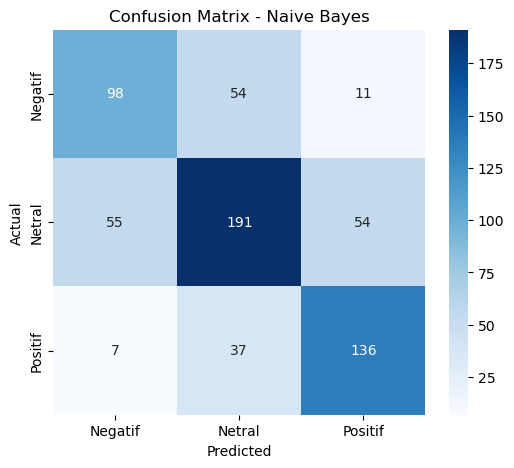

In [ ]:
# 1. Ekstrak tipe model dari hasil Optuna (jika ada) dan hapus key 'nb_type' agar tidak error
# Asumsi 'study.best_params' disimpan di variabel 'nb_best_params'
params = nb_best_params.copy()

if 'nb_type' in params:
    nb_type = params.pop('nb_type')
    if nb_type == 'multinomial':
        nb = MultinomialNB(**params)
    else:
        nb = ComplementNB(**params)
else:
    # Jika Anda mendefinisikan parameter manual
    nb = ComplementNB(**params)

# 2. Evaluasi Model
nb_results, nb_model = evaluate_model(
    model=nb,
    X_tr=X_train_tfidf,
    y_tr=y_train,
    X_te=X_test_tfidf,
    y_te=y_test,
    name="naive_bayes",
    use_sample_weight=True,
    class_weight=CLASS_WEIGHTS
)

# 3. Print Metrics
print("=" * 52)
print("  Naive Bayes — Metrics")
print("=" * 52)
for k, v in nb_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

# 4. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, nb_model.predict(X_test_tfidf),
                             target_names=CLASS_NAMES.values()))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, nb_model.predict(X_test_tfidf))
labels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels, cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

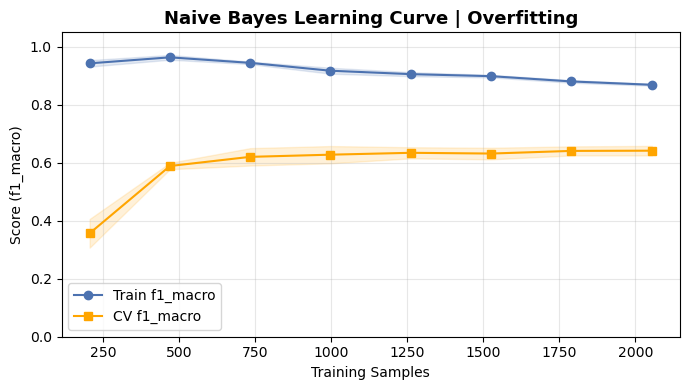

0.22731183842063896

In [ ]:
plot_learning_curve(nb_model, X_train_tfidf, y_train, title="Naive Bayes Learning Curve")

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

# 1. Ambil teks mentah dari DataFrame awal berdasarkan indeks X_test
teks_mentah_test = df.loc[X_test.index, 'reviews.text']

# 2. Gabungkan semuanya ke dalam DataFrame Analisis
df_analysis = pd.DataFrame({
    'Raw_Text': teks_mentah_test,

    # PERBAIKAN: Ambil kolom teks bersih spesifiknya saja (1 Dimensi), jangan 'X_test' utuh
    'Clean_Text': X_test['combinedtext_exp'],

    'Actual_Label': y_test,
    'Predicted_Label': y_pred
})

# 3. Tambahkan kolom penanda BENAR atau SALAH
df_analysis['Is_Correct'] = df_analysis['Actual_Label'] == df_analysis['Predicted_Label']

# 4. Petakan angka (0,1,2) ke teks agar lebih mudah dibaca
LABEL_MAPPING = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
df_analysis['Actual_Label_Name'] = df_analysis['Actual_Label'].map(LABEL_MAPPING)
df_analysis['Predicted_Label_Name'] = df_analysis['Predicted_Label'].map(LABEL_MAPPING)

# 5. Simpan ke CSV
df_analysis.to_csv('hasil_analisis_nb.csv', index=False)

print("File 'hasil_analisis_nb.csv' berhasil dibuat dengan aman!")

File 'hasil_analisis_nb.csv' berhasil dibuat dengan aman!


## Logistic Regression

In [ ]:
def objective(trial):

    # Hyperparameter space
    C = trial.suggest_float("C", 1e-4, 10, log=True)
    solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs", "saga"])

    # penalty harus kompatibel dengan solver
    if solver == "liblinear":
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    elif solver == "saga":
        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    else:  # lbfgs
        penalty = "l2"

    model = LogisticRegression(
        C=C,
        solver=solver,
        penalty=penalty,
        class_weight=CLASS_WEIGHTS,
        max_iter=1000
    )

    score = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        cv=5,
        scoring="f1_macro",
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80)

print("Best Params:", study.best_params)
print("Best Score:", study.best_value)

[I 2026-05-18 18:41:17,340] A new study created in memory with name: no-name-61378085-456d-4956-b4d6-85c875942bf9


[I 2026-05-18 18:41:18,307] Trial 0 finished with value: 0.5562197672256181 and parameters: {'C': 0.017419238389502285, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.5562197672256181.
[I 2026-05-18 18:41:22,033] Trial 1 finished with value: 0.6770691752306544 and parameters: {'C': 1.566299130694885, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.6770691752306544.
[I 2026-05-18 18:41:22,765] Trial 2 finished with value: 0.520593573379714 and parameters: {'C': 0.0003365120890781833, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.6770691752306544.
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/pyth

Best Params: {'C': 1.5977455768816766, 'solver': 'liblinear', 'penalty': 'l1'}
Best Score: 0.6854021471545197


In [ ]:
lg_best_params = study.best_params
lg_best_params

{'C': 1.5977455768816766, 'solver': 'liblinear', 'penalty': 'l1'}

/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be

  Logistic Regression — Metrics
  Train Acc             : 0.7445
  Test Acc              : 0.6765
  Test F1 (macro)       : 0.6795
  Test Precision        : 0.6721
  Test Recall           : 0.6965
  F1 High               : 0.7520
  Recall High           : 0.8000
  Precision High        : 0.7094
  CV Acc (mean)         : 0.6608

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.58      0.70      0.64       163
      Netral       0.72      0.59      0.65       300
     Positif       0.71      0.80      0.75       180

    accuracy                           0.68       643
   macro avg       0.67      0.70      0.68       643
weighted avg       0.68      0.68      0.67       643



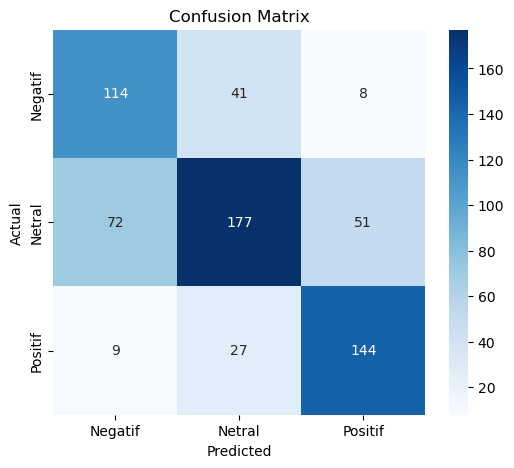

In [ ]:
logistic = LogisticRegression(**lg_best_params,max_iter=1000)
logistic_results, logistic_model = evaluate_model(
    model=logistic,
    X_tr=X_train_tfidf,
    y_tr=y_train,
    X_te=X_test_tfidf,
    y_te=y_test,
    name="Logistic Regression",
    use_sample_weight=True,
    class_weight=CLASS_WEIGHTS
)

print("=" * 52)
print("  Logistic Regression — Metrics")
print("=" * 52)
for k, v in logistic_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, logistic_model.predict(X_test_tfidf),
                             target_names=CLASS_NAMES.values()))


cm = confusion_matrix(y_test, logistic_model.predict(X_test_tfidf))

labels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

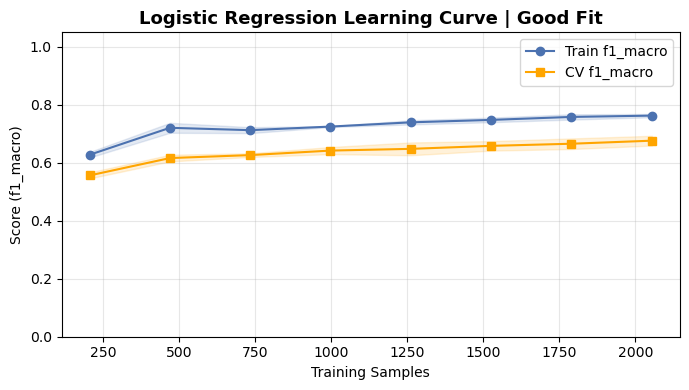

0.08645219455082731

In [ ]:
plot_learning_curve(logistic_model, X_train_tfidf, y_train, title="Logistic Regression Learning Curve")

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

# 1. Ambil teks mentah dari DataFrame awal berdasarkan indeks X_test
teks_mentah_test = df.loc[X_test.index, 'reviews.text']

# 2. Gabungkan semuanya ke dalam DataFrame Analisis
df_analysis = pd.DataFrame({
    'Raw_Text': teks_mentah_test,

    # PERBAIKAN: Ambil kolom teks bersih spesifiknya saja (1 Dimensi), jangan 'X_test' utuh
    'Clean_Text': X_test['combinedtext_exp'],

    'Actual_Label': y_test,
    'Predicted_Label': y_pred
})

# 3. Tambahkan kolom penanda BENAR atau SALAH
df_analysis['Is_Correct'] = df_analysis['Actual_Label'] == df_analysis['Predicted_Label']

# 4. Petakan angka (0,1,2) ke teks agar lebih mudah dibaca
LABEL_MAPPING = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
df_analysis['Actual_Label_Name'] = df_analysis['Actual_Label'].map(LABEL_MAPPING)
df_analysis['Predicted_Label_Name'] = df_analysis['Predicted_Label'].map(LABEL_MAPPING)

# 5. Simpan ke CSV
df_analysis.to_csv('hasil_analisis_lr.csv', index=False)

print("File 'hasil_analisis_lr.csv' berhasil dibuat dengan aman!")

File 'hasil_analisis_lr.csv' berhasil dibuat dengan aman!


## SVM

In [ ]:
def objective(trial):

    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])

    C = trial.suggest_float('C', 1e-3, 1e3, log=True)

    # Conditional parameters
    if kernel == 'rbf':
        gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    elif kernel == 'poly':
        gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
        degree = trial.suggest_int('degree', 2, 5)
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    elif kernel == 'sigmoid':
        gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    else:
        gamma = 'scale'

    model = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        class_weight=CLASS_WEIGHTS
    )

    # Tambahkan parameter jika relevan
    if kernel == 'poly':
        model.degree = degree
        model.coef0 = coef0
    elif kernel == 'sigmoid':
        model.coef0 = coef0

    score = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1_macro')

    return score.mean()

# Study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=80)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-05-18 18:50:58,595] A new study created in memory with name: no-name-0769e212-8b1e-4e15-a8c2-b786f928f798
[I 2026-05-18 18:51:04,290] Trial 0 finished with value: 0.13449359139809797 and parameters: {'kernel': 'rbf', 'C': 0.022902671591333086, 'gamma': 1.7120701139961032}. Best is trial 0 with value: 0.13449359139809797.
[I 2026-05-18 18:51:09,158] Trial 1 finished with value: 0.6126472223381547 and parameters: {'kernel': 'linear', 'C': 56.639127492637584}. Best is trial 1 with value: 0.6126472223381547.
[I 2026-05-18 18:51:13,042] Trial 2 finished with value: 0.6569013532325543 and parameters: {'kernel': 'linear', 'C': 0.36352633754658253}. Best is trial 2 with value: 0.6569013532325543.
[I 2026-05-18 18:51:19,432] Trial 3 finished with value: 0.13449359139809797 and parameters: {'kernel': 'rbf', 'C': 0.004365199943127914, 'gamma': 0.04738926847807827}. Best is trial 2 with value: 0.6569013532325543.
[I 2026-05-18 18:51:23,482] Trial 4 finished with value: 0.6201834376257723 a

Best params: {'kernel': 'rbf', 'C': 183.6419110686765, 'gamma': 0.734140821329467}
Best score: 0.6844061644554033


In [ ]:
svm_best_params = study.best_params
svm_best_params

{'kernel': 'rbf', 'C': 183.6419110686765, 'gamma': 0.734140821329467}

  SVM — Metrics
  Train Acc             : 1.0000
  Test Acc              : 0.7030
  Test F1 (macro)       : 0.6947
  Test Precision        : 0.7142
  Test Recall           : 0.6830
  F1 High               : 0.7442
  Recall High           : 0.7111
  Precision High        : 0.7805
  CV Acc (mean)         : 0.6819

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.69      0.56      0.62       163
      Netral       0.67      0.77      0.72       300
     Positif       0.78      0.71      0.74       180

    accuracy                           0.70       643
   macro avg       0.71      0.68      0.69       643
weighted avg       0.71      0.70      0.70       643



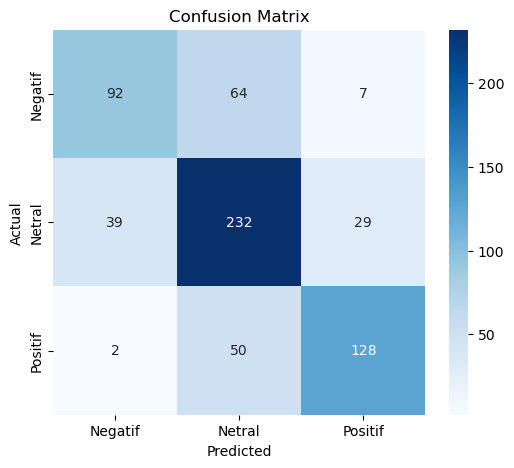

In [ ]:
svm = SVC(**svm_best_params, probability=True, class_weight=CLASS_WEIGHTS)
svm_results, svm_model = evaluate_model(
    model=svm,
    X_tr=X_train_tfidf,
    y_tr=y_train,
    X_te=X_test_tfidf,
    y_te=y_test,
    name="svm",

)

print("=" * 52)
print("  SVM — Metrics")
print("=" * 52)
for k, v in svm_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, svm_model.predict(X_test_tfidf),
                             target_names=CLASS_NAMES.values()))

cm = confusion_matrix(y_test, svm_model.predict(X_test_tfidf))

labels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels, cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

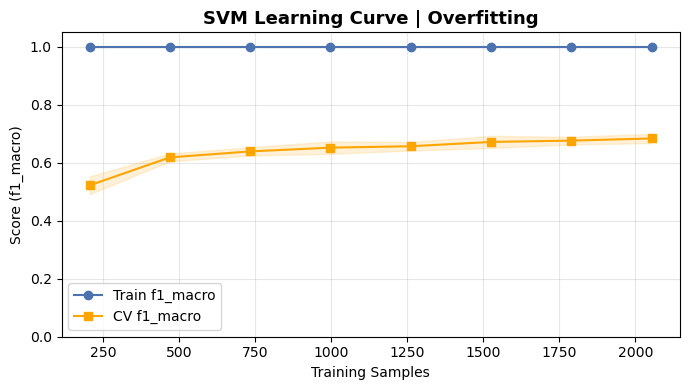

0.31608534139978395

In [ ]:
plot_learning_curve(svm_model, X_train_tfidf, y_train, title="SVM Learning Curve")

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

# 1. Ambil teks mentah dari DataFrame awal berdasarkan indeks X_test
teks_mentah_test = df.loc[X_test.index, 'reviews.text']

# 2. Gabungkan semuanya ke dalam DataFrame Analisis
df_analysis = pd.DataFrame({
    'Raw_Text': teks_mentah_test,

    # PERBAIKAN: Ambil kolom teks bersih spesifiknya saja (1 Dimensi), jangan 'X_test' utuh
    'Clean_Text': X_test['combinedtext_exp'],

    'Actual_Label': y_test,
    'Predicted_Label': y_pred
})

# 3. Tambahkan kolom penanda BENAR atau SALAH
df_analysis['Is_Correct'] = df_analysis['Actual_Label'] == df_analysis['Predicted_Label']

# 4. Petakan angka (0,1,2) ke teks agar lebih mudah dibaca
LABEL_MAPPING = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
df_analysis['Actual_Label_Name'] = df_analysis['Actual_Label'].map(LABEL_MAPPING)
df_analysis['Predicted_Label_Name'] = df_analysis['Predicted_Label'].map(LABEL_MAPPING)

# 5. Simpan ke CSV
df_analysis.to_csv('hasil_analisis_svm.csv', index=False)

print("File 'hasil_analisis_svm.csv' berhasil dibuat dengan aman!")

File 'hasil_analisis_svm.csv' berhasil dibuat dengan aman!


## 'Random Forest'

In [ ]:
# def objective(trial):

#     model = RandomForestClassifier(
#         n_estimators=trial.suggest_int('n_estimators', 100, 1000),
#         max_depth=trial.suggest_int('max_depth', 5, 50),
#         max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#         min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
#         min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 20),
#         bootstrap=trial.suggest_categorical('bootstrap', [True, False]),
#         class_weight=CLASS_WEIGHTS
#     )

#     score = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
#     return score.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=80)

# print("Best params:", study.best_params)
# print("Best score:", study.best_value)

In [ ]:
# rf_best_params = study.best_params
# rf_best_params

{'n_estimators': 333,
 'max_depth': 43,
 'max_features': 'sqrt',
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'bootstrap': False}

In [ ]:
rf_best_params = {'n_estimators': 333,
 'max_depth': 43,
 'max_features': 'sqrt',
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'bootstrap': False}

  Random Forest — Metrics
  Train Acc             : 0.9992
  Test Acc              : 0.7092
  Test F1 (macro)       : 0.7063
  Test Precision        : 0.7110
  Test Recall           : 0.7023
  F1 High               : 0.7535
  Recall High           : 0.7389
  Precision High        : 0.7688
  CV Acc (mean)         : 0.6826

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.67      0.64      0.65       163
      Netral       0.70      0.73      0.71       300
     Positif       0.77      0.74      0.75       180

    accuracy                           0.71       643
   macro avg       0.71      0.70      0.71       643
weighted avg       0.71      0.71      0.71       643



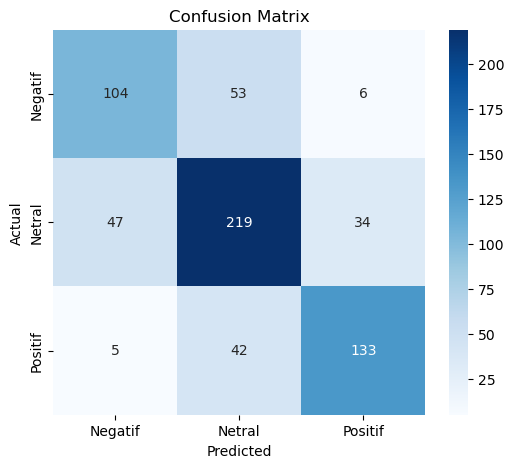

In [ ]:
rf = RandomForestClassifier(**rf_best_params, class_weight=CLASS_WEIGHTS)
rf_results, rf_model = evaluate_model(
    model=rf,
    X_tr=X_train_tfidf,
    y_tr=y_train,
    X_te=X_test_tfidf,
    y_te=y_test,
    name="Random Forest classifier",
)

print("=" * 52)
print("  Random Forest — Metrics")
print("=" * 52)
for k, v in rf_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_model.predict(X_test_tfidf),
                             target_names=CLASS_NAMES.values()))

cm = confusion_matrix(y_test, rf_model.predict(X_test_tfidf))

labels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels, cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import joblib
joblib.dump(rf_model, 'best_nb_model.pkl')

['best_nb_model.pkl']

/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

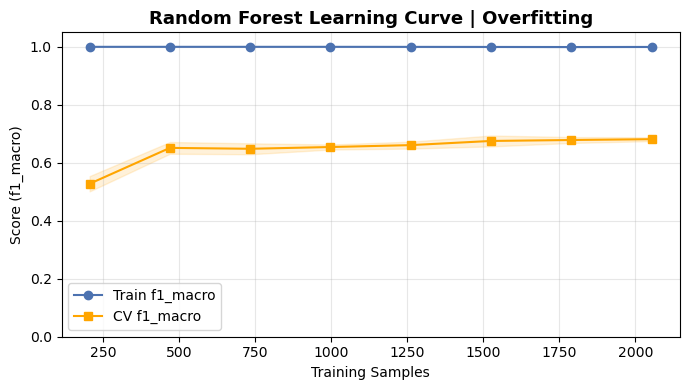

0.3181806903694412

In [ ]:
plot_learning_curve(rf_model, X_train_tfidf, y_train, title="Random Forest Learning Curve")

In [ ]:
y_pred = rf_model.predict(X_test_tfidf)

# 2. Gabungkan ke DataFrame secara AMAN (Gunakan .reset_index(drop=True) agar sejajar 1-to-1)
df_analysis = pd.DataFrame({
    # Langsung ambil raw text yang sudah ada di dalam X_test, tidak perlu ke df lagi
    'Raw_Text': X_test['combined_raw'].reset_index(drop=True),

    'Clean_Text': X_test['combinedtext_exp'].reset_index(drop=True),

    'Actual_Label': y_test.reset_index(drop=True),

    'Predicted_Label': y_pred # y_pred bentuknya sudah array, jadi otomatis sinkron
})

# 3. Tambahkan kolom penanda BENAR atau SALAH
df_analysis['Is_Correct'] = df_analysis['Actual_Label'] == df_analysis['Predicted_Label']

# 4. Petakan angka (0,1,2) ke teks agar lebih mudah dibaca
LABEL_MAPPING = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
df_analysis['Actual_Label_Name'] = df_analysis['Actual_Label'].map(LABEL_MAPPING)
df_analysis['Predicted_Label_Name'] = df_analysis['Predicted_Label'].map(LABEL_MAPPING)

# 5. Simpan ke CSV
df_analysis.to_csv('hasil_analisis_rf_900.csv', index=False)

print("File 'hasil_analisis_rf_900.csv' berhasil dibuat! Index sekarang dijamin sinkron 100%.")

File 'hasil_analisis_rf_900.csv' berhasil dibuat! Index sekarang dijamin sinkron 100%.


## XGBoost

In [ ]:
def objective(trial):

    model = XGBClassifier(
        # core
        n_estimators=trial.suggest_int("n_estimators", 500, 2500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 15),

        # =======================================================
        # PERBAIKAN PENGATURAN EARLY STOPPING DI SINI (XGBOOST BARU)
        # =======================================================
        early_stopping_rounds=10,
        # =======================================================

        # tree complexity
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),

        # sampling
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        colsample_bylevel=trial.suggest_float("colsample_bylevel", 0.5, 1.0),

        # regularization
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),

        # additional
        max_delta_step=trial.suggest_int("max_delta_step", 0, 10),

        tree_method=trial.suggest_categorical("tree_method", ["auto", "hist"]),

        objective='multi:softprob',
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    y_train_arr = np.array(y_train)

    for train_idx, val_idx in skf.split(X_train_tfidf, y_train_arr):

        X_tr = X_train_tfidf[train_idx]
        X_val = X_train_tfidf[val_idx]

        y_tr = y_train_arr[train_idx]
        y_val = y_train_arr[val_idx]

        sample_weight = np.array([CLASS_WEIGHTS[y] for y in y_tr])

        # =======================================================
        # SEKARANG DI .FIT() HANYA RELEVAN MENERIMA EVAL_SET
        # =======================================================
        model.fit(
            X_tr, y_tr,
            sample_weight=sample_weight,
            eval_set=[(X_val, y_val)],       # Tetap butuh data validasi untuk dipantau
            verbose=False                   # Menyembunyikan log per iterasi
        )

        y_pred = model.predict(X_val)

        score = f1_score(y_val, y_pred, average="macro")
        scores.append(score)

    return np.mean(scores)

# Eksekusi
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-05-18 19:44:25,151] A new study created in memory with name: no-name-80de157c-4fa4-4032-acca-6eed78bc7659
[I 2026-05-18 19:44:56,336] Trial 0 finished with value: 0.6556374956012345 and parameters: {'n_estimators': 2134, 'learning_rate': 0.18326960854793206, 'max_depth': 15, 'min_child_weight': 5, 'gamma': 0.6900509109445119, 'subsample': 0.7751523846212314, 'colsample_bytree': 0.9489219786896483, 'colsample_bylevel': 0.810609171358264, 'reg_alpha': 1.2243953755824688, 'reg_lambda': 2.647709819983927, 'max_delta_step': 3, 'tree_method': 'hist'}. Best is trial 0 with value: 0.6556374956012345.
[I 2026-05-18 19:45:08,176] Trial 1 finished with value: 0.6390216188370748 and parameters: {'n_estimators': 2290, 'learning_rate': 0.13552211578465262, 'max_depth': 9, 'min_child_weight': 1, 'gamma': 3.721602447459145, 'subsample': 0.9931226137322448, 'colsample_bytree': 0.9917881789223504, 'colsample_bylevel': 0.691389225343976, 'reg_alpha': 4.613770896613728, 'reg_lambda': 2.93352074973

Best params: {'n_estimators': 2161, 'learning_rate': 0.013900076660489327, 'max_depth': 12, 'min_child_weight': 1, 'gamma': 1.6349439191009731, 'subsample': 0.7490627759607635, 'colsample_bytree': 0.6307541027709475, 'colsample_bylevel': 0.6783059386959837, 'reg_alpha': 0.6689113508887772, 'reg_lambda': 1.1360619152452553, 'max_delta_step': 3, 'tree_method': 'hist'}
Best score: 0.6802695822805774


In [ ]:
xgb_best_params = study.best_params
xgb_best_params

{'n_estimators': 2161,
 'learning_rate': 0.013900076660489327,
 'max_depth': 12,
 'min_child_weight': 1,
 'gamma': 1.6349439191009731,
 'subsample': 0.7490627759607635,
 'colsample_bytree': 0.6307541027709475,
 'colsample_bylevel': 0.6783059386959837,
 'reg_alpha': 0.6689113508887772,
 'reg_lambda': 1.1360619152452553,
 'max_delta_step': 3,
 'tree_method': 'hist'}

  XGBoost — Metrics
  Train Acc             : 0.9023
  Test Acc              : 0.6936
  Test F1 (macro)       : 0.6929
  Test Precision        : 0.6879
  Test Recall           : 0.7005
  F1 High               : 0.7500
  Recall High           : 0.7667
  Precision High        : 0.7340
  CV Acc (mean)         : 0.6764

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.60      0.67      0.64       163
      Netral       0.73      0.66      0.69       300
     Positif       0.73      0.77      0.75       180

    accuracy                           0.69       643
   macro avg       0.69      0.70      0.69       643
weighted avg       0.70      0.69      0.69       643



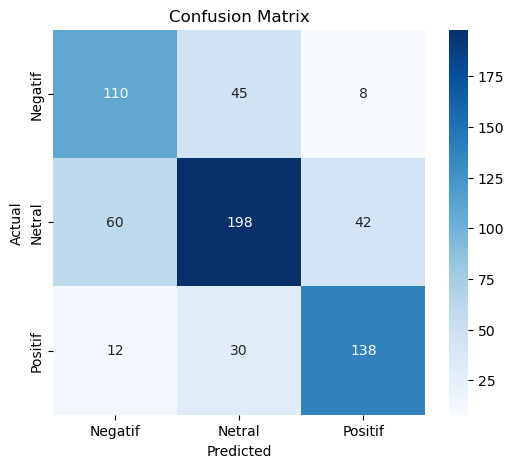

In [ ]:
xgb = XGBClassifier(**xgb_best_params)
xgb_results, xgb_model = evaluate_model(
    model=xgb,
    X_tr=X_train_tfidf,
    y_tr=y_train,
    X_te=X_test_tfidf,
    y_te=y_test,
    name="xgboost",
    class_weight=CLASS_WEIGHTS,
    use_sample_weight=True
)

print("=" * 52)
print("  XGBoost — Metrics")
print("=" * 52)
for k, v in xgb_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_model.predict(X_test_tfidf),
                             target_names=CLASS_NAMES.values()))

cm = confusion_matrix(y_test, xgb_model.predict(X_test_tfidf))

labels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels, cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

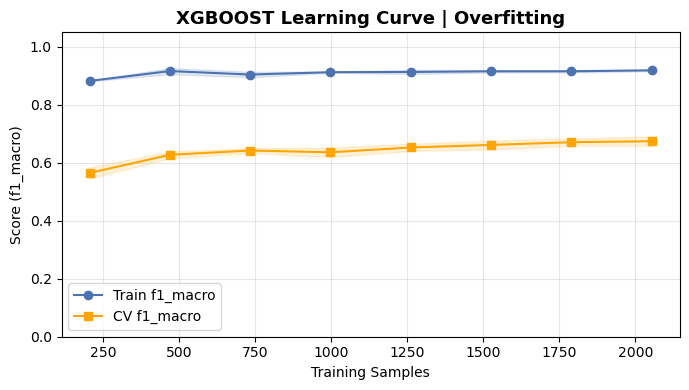

0.24446724754337068

In [ ]:
plot_learning_curve(xgb_model, X_train_tfidf, y_train, title="XGBOOST Learning Curve")

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

# 1. Ambil teks mentah dari DataFrame awal berdasarkan indeks X_test
teks_mentah_test = df.loc[X_test.index, 'reviews.text']

# 2. Gabungkan semuanya ke dalam DataFrame Analisis
df_analysis = pd.DataFrame({
    'Raw_Text': teks_mentah_test,

    # PERBAIKAN: Ambil kolom teks bersih spesifiknya saja (1 Dimensi), jangan 'X_test' utuh
    'Clean_Text': X_test['combinedtext_exp'],

    'Actual_Label': y_test,
    'Predicted_Label': y_pred
})

# 3. Tambahkan kolom penanda BENAR atau SALAH
df_analysis['Is_Correct'] = df_analysis['Actual_Label'] == df_analysis['Predicted_Label']

# 4. Petakan angka (0,1,2) ke teks agar lebih mudah dibaca
LABEL_MAPPING = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
df_analysis['Actual_Label_Name'] = df_analysis['Actual_Label'].map(LABEL_MAPPING)
df_analysis['Predicted_Label_Name'] = df_analysis['Predicted_Label'].map(LABEL_MAPPING)

# 5. Simpan ke CSV
df_analysis.to_csv('hasil_analisis_xgb.csv', index=False)

print("File 'hasil_analisis_xgb.csv' berhasil dibuat dengan aman!")

File 'hasil_analisis_xgb.csv' berhasil dibuat dengan aman!


## LightGBM

In [ ]:
import optuna
import numpy as np
import lightgbm as lgb # Kita butuh mengimpor ini untuk mengambil fungsi callbacks
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def objective(trial):

    model = LGBMClassifier(
        # core
        # n_estimators kita perbesar karena early stopping yang akan mengeremnya
        n_estimators=trial.suggest_int("n_estimators", 500, 3000),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        num_leaves=trial.suggest_int("num_leaves", 20, 150),

        # tree complexity
        min_child_weight=trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        min_split_gain=trial.suggest_float("min_split_gain", 0.0, 5.0),

        # sampling
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        subsample_freq=trial.suggest_int("subsample_freq", 1, 10),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # regularization
        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 5.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.0, 5.0),

        # config
        objective='multiclass',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    y_train_arr = np.array(y_train)

    for train_idx, val_idx in skf.split(X_train_tfidf, y_train_arr):

        X_tr = X_train_tfidf[train_idx]
        X_val = X_train_tfidf[val_idx]

        y_tr = y_train_arr[train_idx]
        y_val = y_train_arr[val_idx]

        sample_weight = np.array([CLASS_WEIGHTS[y] for y in y_tr])

        # ==========================================
        # IMPLEMENTASI EARLY STOPPING DI SINI
        # ==========================================
        model.fit(
            X_tr, y_tr,
            sample_weight=sample_weight,
            eval_set=[(X_val, y_val)], # Beritahu model data validasinya
            callbacks=[
                # Berhenti jika selama 50 pohon (rounds) skor tidak membaik
                lgb.early_stopping(stopping_rounds=10, verbose=False),
                # Sembunyikan print metric log bawaan agar output Anda tidak kotor
                lgb.log_evaluation(period=0)
            ]
        )

        y_pred = model.predict(X_val)

        score = f1_score(y_val, y_pred, average="macro")
        scores.append(score)

    return np.mean(scores)

# Eksekusi Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-05-18 21:23:34,149] A new study created in memory with name: no-name-7bf25831-3fe3-4952-93be-094e1d762778
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/env

Best params: {'n_estimators': 2268, 'learning_rate': 0.05785572151614004, 'max_depth': 12, 'num_leaves': 116, 'min_child_weight': 0.5548621363721888, 'min_split_gain': 1.501904790091804, 'subsample': 0.720983556705611, 'subsample_freq': 3, 'colsample_bytree': 0.5599808394739219, 'reg_alpha': 0.03515470611927177, 'reg_lambda': 1.3191720555593787}
Best score: 0.6721106108786946


In [ ]:
lgbm_best_params = study.best_params

/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid featur

  LightGBM — Metrics
  Train Acc             : 0.8867
  Test Acc              : 0.6936
  Test F1 (macro)       : 0.6945
  Test Precision        : 0.6887
  Test Recall           : 0.7037
  F1 High               : 0.7371
  Recall High           : 0.7556
  Precision High        : 0.7196
  CV Acc (mean)         : 0.6717

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.62      0.71      0.66       163
      Netral       0.72      0.65      0.69       300
     Positif       0.72      0.76      0.74       180

    accuracy                           0.69       643
   macro avg       0.69      0.70      0.69       643
weighted avg       0.70      0.69      0.69       643



/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


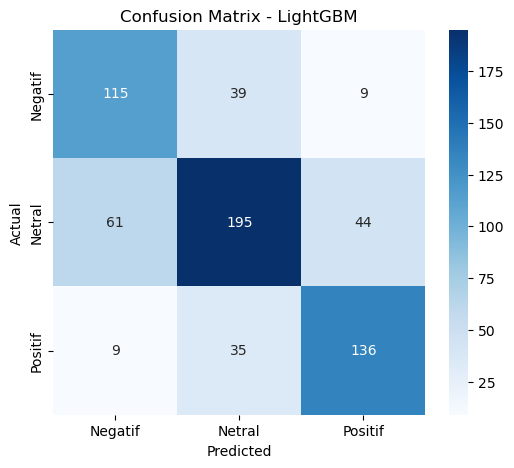

In [ ]:
lgbm = LGBMClassifier(
    **lgbm_best_params,
    objective='multiclass',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_results, lgbm_model = evaluate_model(
    model=lgbm,
    X_tr=X_train_tfidf,
    y_tr=y_train,
    X_te=X_test_tfidf,
    y_te=y_test,
    name="lightgbm",
    class_weight=CLASS_WEIGHTS,
    use_sample_weight=True
)

# ==========================================
# 3. CETAK METRIK & VISUALISASI
# ==========================================
print("=" * 52)
print("  LightGBM — Metrics")
print("=" * 52)
for k, v in lgbm_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lgbm_model.predict(X_test_tfidf),
                             target_names=CLASS_NAMES.values()))

cm = confusion_matrix(y_test, lgbm_model.predict(X_test_tfidf))
labels = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels, cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - LightGBM')
plt.show()

In [ ]:
plot_learning_curve(lgbm_model, X_train_tfidf, y_train, title="LightGBM Learning Curve")

/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

KeyboardInterrupt: 

In [ ]:
y_pred = nb_model.predict(X_test_tfidf)

# 1. Ambil teks mentah dari DataFrame awal berdasarkan indeks X_test
teks_mentah_test = df.loc[X_test.index, 'reviews.text']

# 2. Gabungkan semuanya ke dalam DataFrame Analisis
df_analysis = pd.DataFrame({
    'Raw_Text': teks_mentah_test,

    # PERBAIKAN: Ambil kolom teks bersih spesifiknya saja (1 Dimensi), jangan 'X_test' utuh
    'Clean_Text': X_test['combinedtext_exp'],

    'Actual_Label': y_test,
    'Predicted_Label': y_pred
})

# 3. Tambahkan kolom penanda BENAR atau SALAH
df_analysis['Is_Correct'] = df_analysis['Actual_Label'] == df_analysis['Predicted_Label']

# 4. Petakan angka (0,1,2) ke teks agar lebih mudah dibaca
LABEL_MAPPING = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
df_analysis['Actual_Label_Name'] = df_analysis['Actual_Label'].map(LABEL_MAPPING)
df_analysis['Predicted_Label_Name'] = df_analysis['Predicted_Label'].map(LABEL_MAPPING)

# 5. Simpan ke CSV
df_analysis.to_csv('hasil_analisis_lgb.csv', index=False)

print("File 'hasil_analisis_lgb.csv' berhasil dibuat dengan aman!")

File 'hasil_analisis_lgb.csv' berhasil dibuat dengan aman!


# Analisis Hasil Best Model

In [ ]:
df_analysis = pd.read_csv('hasil_analisis_rf_900.csv')
df_analysis

,Raw_Text,Clean_Text,Actual_Label,Predicted_Label,Is_Correct,Actual_Label_Name,Predicted_Label_Name
0,Not Worth the Price Bought this an an auxiliar...,worth price buy auxiliary pad instead second i...,1,1,True,Netral,Netral
1,It isn't bad It is okay so to speak. It does w...,bad okay speak say feel much potential however...,1,1,True,Netral,Netral
2,Great for toddlers I like it. Bought it as a b...,great toddler like buy birthday gift three yea...,1,2,False,Netral,Positif
3,very nice tablet for the price The new tablet ...,nice tablet price new tablet great nice upgrad...,2,2,True,Positif,Positif
4,SPAM Edition SPECIAL OFFERS means there are po...,spam edition special offer mean popup ad turn ...,0,0,True,Negatif,Negatif
...,...,...,...,...,...,...,...
638,Product good apps not!!! Good for the price. A...,product good apps good price amazon apps much ...,2,1,False,Positif,Netral
639,What a piece of junk Except unlike the Millenn...,piece junk except unlike millennium falcon cou...,0,0,True,Negatif,Negatif
640,Still prefer iPad or android tablet Works well...,still prefer ipad android tablet work well off...,1,1,True,Netral,Netral
641,Great tablet for toddler My daughter lovethis ...,great tablet toddler daughter lovethis tablet ...,1,2,False,Netral,Positif


/tmp/ipykernel_6963/4173233918.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_counts, x='Label Asli', y='Jumlah Salah', palette='Reds_r')


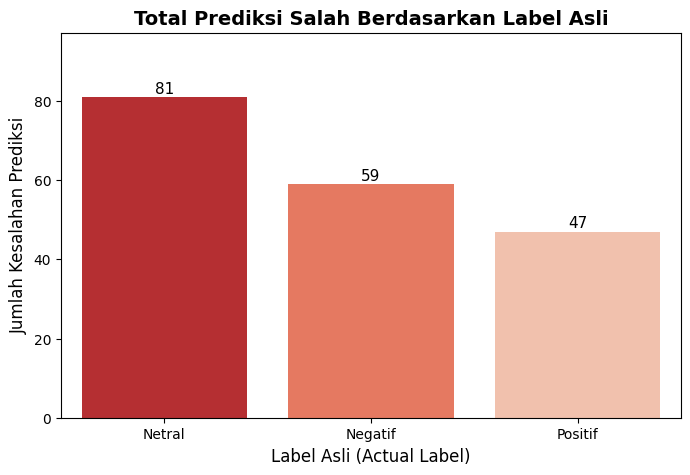

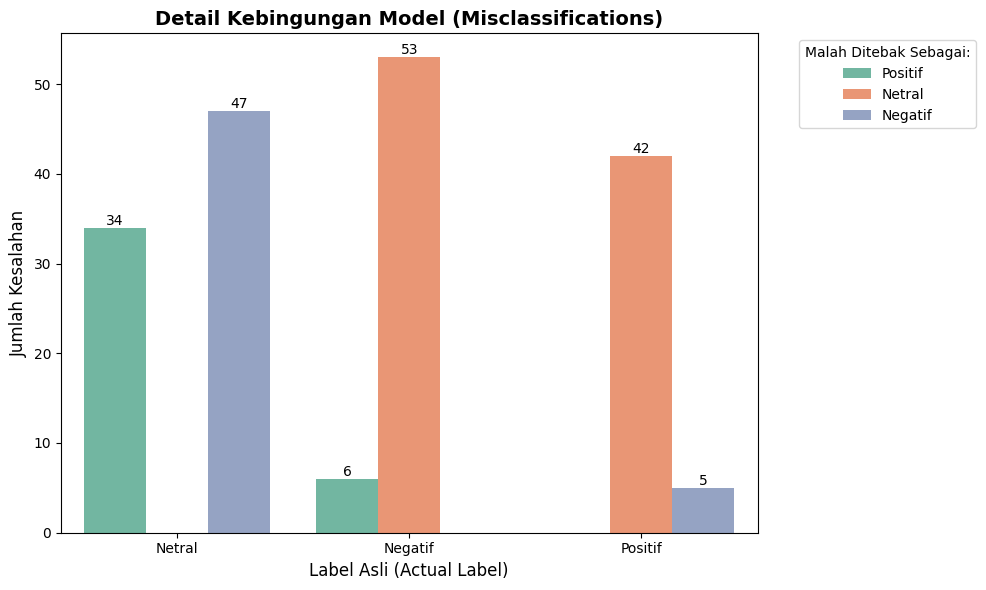

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter hanya data yang tebakannya SALAH
df_errors = df_analysis[df_analysis['Is_Correct'] == False]

# ==========================================
# VISUALISASI 1: Label Asli Mana yang Paling Sering Salah Ditebak?
# ==========================================
plt.figure(figsize=(8, 5))
# Kita hitung jumlah error per kelas aslinya
error_counts = df_errors['Actual_Label_Name'].value_counts().reset_index()
error_counts.columns = ['Label Asli', 'Jumlah Salah']

# Membuat Bar plot dengan warna gradasi merah (menandakan error)
sns.barplot(data=error_counts, x='Label Asli', y='Jumlah Salah', palette='Reds_r')

plt.title('Total Prediksi Salah Berdasarkan Label Asli', fontsize=14, fontweight='bold')
plt.xlabel('Label Asli (Actual Label)', fontsize=12)
plt.ylabel('Jumlah Kesalahan Prediksi', fontsize=12)

# Menambahkan angka di atas setiap bar
for index, row in error_counts.iterrows():
    plt.text(index, row['Jumlah Salah'] + 1, str(row['Jumlah Salah']), color='black', ha="center", fontsize=11)

plt.ylim(0, error_counts['Jumlah Salah'].max() * 1.2) # Memberi ruang di atas bar
plt.show()

# ==========================================
# VISUALISASI 2: Model Bingungnya ke Arah Mana? (Grouped Bar)
# ==========================================
plt.figure(figsize=(10, 6))

# Membuat chart yang menunjukkan "Aslinya apa, tapi malah ditebak apa"
ax = sns.countplot(
    data=df_errors,
    x='Actual_Label_Name',
    hue='Predicted_Label_Name',
    palette='Set2' # Warna pastel yang cantik dan mudah dibedakan
)

plt.title('Detail Kebingungan Model (Misclassifications)', fontsize=14, fontweight='bold')
plt.xlabel('Label Asli (Actual Label)', fontsize=12)
plt.ylabel('Jumlah Kesalahan', fontsize=12)
plt.legend(title='Malah Ditebak Sebagai:', bbox_to_anchor=(1.05, 1), loc='upper left')

# Menambahkan angka di atas bar
for p in ax.patches:
    if p.get_height() > 0: # Hanya tampilkan angka jika > 0
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Atur Pandas agar menampilkan teks sepanjang apa pun secara utuh (tidak dipotong)
pd.set_option('display.max_colwidth', None)

# 2. Filter hanya data yang tebakannya SALAH
df_errors = df_analysis[df_analysis['Is_Correct'] == False]

# 3. Ambil 5 sampel secara acak (beserta label aslinya agar konteksnya jelas)
kolom_penting = ['Raw_Text', 'Clean_Text', 'Actual_Label_Name', 'Predicted_Label_Name']
sampel_acak_error = df_errors[kolom_penting].sample(n=5, random_state=42)
# Catatan: Hapus random_state=42 jika Anda ingin hasilnya selalu berubah setiap kali kode di-run

# 4. Tampilkan tabel
display(sampel_acak_error)

# Kembalikan pengaturan tampilan Pandas ke normal (opsional)
pd.reset_option('display.max_colwidth')

,Raw_Text,Clean_Text,Actual_Label_Name,Predicted_Label_Name
638,Product good apps not!!! Good for the price. Amazon apps aren't much. The big thing Amazon doesn't let you use Google Play for apps.,product good apps good price amazon apps much big thing amazon let use google play apps,Positif,Netral
284,So far so good Ordering process was easy and as expected. Hopefully my husband will install it soon.,far good order process easy expect hopefully husband install soon,Netral,Positif
202,"Cut the cable cord I bought the Amazon Firebox so I could finally get rid of cable. when I think of all the $$ I will save on cable I may buy another one for 2nd tv. A bit challenging learning how to operate it, Once I do I know I will love it. Thanks Amazon",cut cable cord buy amazon firebox could finally get rid cable think save cable may buy another one 2nd tv bite challenge learn operate know love thank amazon,Positif,Netral
470,Good little device for a quick email check. I chose this to check email and Facebook because I don't have a smartphone. It's a lot quicker than getting on my laptop. I use it for YouTube and Pandora also. My only complaint is my old eyes struggle with the smaller print. I am pleased with it!,good little device quick email check choose check email facebook smartphone lot quicker get laptop use youtube pandora also complaint old eye struggle smaller print please,Positif,Netral
551,"It's ok, but it jump pages too easily. I had a lower end kindle for years. When that broke, I decide to buy the higher end one that is backlit. The back litghting is nice for reading at night. But the touch features are too jumpy--it jumps pages instead of just turning to the next one. It is cumbersome to buy through amazon and difficult to see the list of what you have. I don't know if I'd buy this one over the lowest end one again.",ok jump page easily lower end kindle year break decide buy higher end one backlit back litghting nice read night touch feature jumpyit jump page instead turn next one cumbersome buy amazon difficult see list know id buy one lowest end one,Netral,Negatif


=== RINGKASAN PERSENTASE KATA YANG TERBUANG ===


,Tebakan Benar?,Rata-rata Kata Hilang (%)
0,False,47.422832
1,True,47.260441


/tmp/ipykernel_6963/3755642651.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


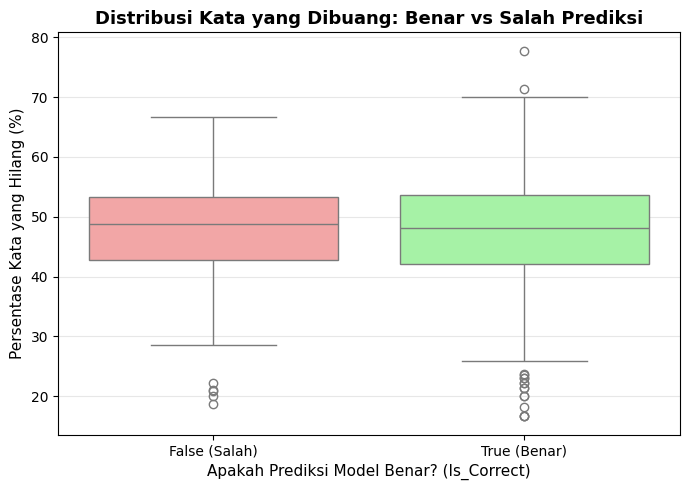

In [ ]:
# 1. Pastikan tipe datanya string dan hitung jumlah kata (Word Count)
df_analysis['Raw_Text'] = df_analysis['Raw_Text'].fillna("")
df_analysis['Clean_Text'] = df_analysis['Clean_Text'].fillna("")

df_analysis['WordCount_Raw'] = df_analysis['Raw_Text'].apply(lambda x: len(str(x).split()))
df_analysis['WordCount_Clean'] = df_analysis['Clean_Text'].apply(lambda x: len(str(x).split()))

# 2. Hitung persentase kata yang terbuang/hilang saat preprocessing
# Gunakan np.where untuk menghindari error pembagian dengan 0 jika ada teks yang kosong
df_analysis['Word_Loss_Percentage'] = np.where(
    df_analysis['WordCount_Raw'] > 0,
    ((df_analysis['WordCount_Raw'] - df_analysis['WordCount_Clean']) / df_analysis['WordCount_Raw']) * 100,
    0
)

# 3. Tampilkan angka rata-ratanya dalam bentuk tabel
summary_diff = df_analysis.groupby('Is_Correct')['Word_Loss_Percentage'].mean().reset_index()
summary_diff.columns = ['Tebakan Benar?', 'Rata-rata Kata Hilang (%)']
print("=== RINGKASAN PERSENTASE KATA YANG TERBUANG ===")
display(summary_diff)

# 4. Visualisasikan menggunakan Boxplot agar terlihat sebarannya
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df_analysis,
    x='Is_Correct',
    y='Word_Loss_Percentage',
    palette=['#ff9999', '#99ff99'] # Merah untuk False, Hijau untuk True
)

plt.title('Distribusi Kata yang Dibuang: Benar vs Salah Prediksi', fontsize=13, fontweight='bold')
plt.xlabel('Apakah Prediksi Model Benar? (Is_Correct)', fontsize=11)
plt.ylabel('Persentase Kata yang Hilang (%)', fontsize=11)
plt.xticks([0, 1], ['False (Salah)', 'True (Benar)'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()